In [1]:
import os
import json
from datetime import datetime
from dotenv import load_dotenv
import time
import requests
import numpy as np
import pandas as pd
import hmac
import hashlib
from datetime import datetime, timezone
from tqdm.notebook import tqdm
from matplotlib import pyplot as plt
import seaborn as sns
import sqlite3
import subprocess
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, Normalizer
from sklearn.pipeline import Pipeline
import fasttext
from transformers import AutoTokenizer, AutoModel
import pickle
import pyarrow

load_dotenv()

def set_plot_chinese():
    plt.rcParams['font.family'] = ['SimHei']
    plt.rcParams['axes.unicode_minus'] = False
def set_plot_english():
    plt.rcParams['font.family'] = 'DejaVu Sans'

UNAVAILABLE_FIELD = pd.NA

medicine_category_cn = {'flu': "流感", 'diabetes': "糖尿病", "eczema": "湿疹"}

EN_LANGUAGE_CONF_CUTOFF = 0.4
CN_LANGUAGE_CONF_CUTOFF = 0.4

In [ ]:
# For Colab; do NOT run locally!
import numpy as np
import pandas as pd
import torch
import os
from tqdm.notebook import tqdm
from transformers import AutoTokenizer, AutoModel
device = "cuda" if torch.cuda.is_available() else "cpu"

from google.colab import drive
drive.mount('/content/drive')
os.chdir('drive/MyDrive/complit-4300') # change this to your Drive path
os.getcwd()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


FileNotFoundError: [Errno 2] No such file or directory: 'drive/MyDrive/complit-4300'

In [2]:
def anonymize_username(username, secret_key = os.getenv("SECRET_KEY")):
    key_bytes = secret_key.encode('utf-8')
    data_bytes = username.encode('utf-8')
    hmac_object = hmac.new(key_bytes, data_bytes, hashlib.sha256)
    anonymized_id = hmac_object.hexdigest()
    return anonymized_id

In [3]:
with open("scrape_keywords/medicine_comparisons.json", "r") as file:
    keywords = json.load(file)
keywords[1]

{'condition': 'diabetes',
 'tcm': [{'cn': ['消渴丸'],
   'en': ['Xiaoke Wan',
    'Xiaoke Pill',
    'Xiao Ke',
    'LW Thirst Relief Dietary Supplement']},
  {'cn': ['六味地黄丸'],
   'en': ['Liuwei Dihuang Wan',
    'Six Ingredient Rehmannia',
    'Rehmannia Six Formula',
    'Six Flavor Rehmannia Teapills',
    'Longevity Blend']},
  {'cn': ['黄连', '黄连素'],
   'en': ['Coptis',
    'Coptis Rhizome',
    'Huanglian',
    'Huang Lian',
    'Coptis chinensis',
    'Chinese Goldthread',
    'Coptis Root',
    'Berberine']}],
 'ebm': [{'cn': ['二甲双胍', '格华止'],
   'en': ['Metformin',
    'Glucophage',
    'metformin hydrochloride',
    'Glucophage XR',
    'Fortamet',
    'Glumetza',
    'Riomet',
    'Axpinet',
    'Diagemet',
    'Glucient',
    'Metabet']},
  {'cn': ['格列美脲', '亚莫利'], 'en': ['Glimepiride', 'Amaryl']},
  {'cn': ['胰岛素'],
   'en': ['Insulin',
    'lispro',
    'aspart',
    'glulisine',
    'glargine',
    'detemir',
    'Humalog',
    'NovoLog',
    'Lantus',
    'Tresiba',
    'Fiasp'

In [4]:
with open("scrape_keywords/medicine_flattened.json") as file:
    keyword_flattened = json.loads(file.read())

In [5]:
uname_map = {}
for keyword_group in keywords:
    tcm = keyword_group['tcm']
    for med in tcm:
        for name in med['cn']:
            uname_map[name] = med['cn'][0]
        for name in med['en']:
            uname_map[name] = med['en'][0]
    ebm = keyword_group['ebm']
    for med in ebm:
        for name in med['cn']:
            uname_map[name] = med['cn'][0]
        for name in med['en']:
            uname_map[name] = med['en'][0]

In [6]:
en_uname_map = {}
for keyword_group in keywords:
    tcm = keyword_group['tcm']
    for med in tcm:
        for name in med['cn']:
            en_uname_map[name] = med['en'][0]
        for name in med['en']:
            en_uname_map[name] = med['en'][0]
    ebm = keyword_group['ebm']
    for med in ebm:
        for name in med['cn']:
            en_uname_map[name] = med['en'][0]
        for name in med['en']:
            en_uname_map[name] = med['en'][0]

In [7]:
cond_map = {}
for keyword_group in keywords:
    cond = keyword_group['condition']
    tcm = keyword_group['tcm']
    for med in tcm:
        for name in med['cn']:
            cond_map[name] = cond
        for name in med['en']:
            cond_map[name] = cond
    ebm = keyword_group['ebm']
    for med in ebm:
        for name in med['cn']:
            cond_map[name] = cond
        for name in med['en']:
            cond_map[name] = cond

In [8]:
type_map = {}
for keyword_group in keywords:
    tcm = keyword_group['tcm']
    for med in tcm:
        for name in med['cn']:
            type_map[name] = "tcm"
        for name in med['en']:
            type_map[name] = "tcm"
    ebm = keyword_group['ebm']
    for med in ebm:
        for name in med['cn']:
            type_map[name] = "ebm"
        for name in med['en']:
            type_map[name] = "ebm"

# Scrape Reddit for English posts

In [ ]:
set_plot_english()

In [5]:
reddit_json_url = "https://www.reddit.com/r/medicine/search.json"
headers = {
    'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36'
}
params_format = {
    "sort": "new",
    "t": "all",
    "limit": "100"
}
fields_to_keep = [
    'subreddit', 'selftext', 'body', 'author_fullname', 'title', 'downs', 'ups', 'created_utc', 'permalink', 'id'
]

def scrape_reddit(keyword, mode, medicine_type, year_cutoff = 2019):
    params = {key: value for key, value in params_format.items()}
    params["q"] = keyword
    last_date = "None Scraped"
    after_token = None
    pbar = tqdm()

    while True:
        try:
            time.sleep(np.random.random(1)[0] * 9 + 1)
            resp = requests.get(reddit_json_url, headers = headers, params = params)
            if resp.status_code == 429:
                raise Exception("Hit Reddit Rate Limit (429)! Stopping.")
            data = resp.json()
            children = data['data']['children']
            for child in children:
                post = child['data']
                saved = {"kind": child['kind'], "language": mode, "medicine_type": medicine_type, "keyword_complete": keyword}
                for field in fields_to_keep:
                    saved[field] = post.get(field, "unknown")
                saved['author_fullname'] = anonymize_username(saved['author_fullname'])
                
                timestamp = datetime.fromtimestamp(post.get('created_utc'), tz=timezone.utc)
                last_date = timestamp.strftime('%Y-%m-%d %H:%M:%S %Z')
                saved['year'] = timestamp.year
                saved['month'] = timestamp.month
                saved['day'] = timestamp.day
                if timestamp.year < year_cutoff:
                    pbar.close()
                    return
                with open(os.path.join('data', f'{mode}_{medicine_type}.jsonl'), 'a') as file:
                    file.write(json.dumps(saved) + '\n')
            
            after_token = data['data'].get('after')
            # scraped everything
            if after_token == None:
                pbar.close()
                return
            params['after'] = after_token

            pbar.set_description(f"Scraped {last_date}, last token {after_token}") 
            pbar.update(1)
        except Exception as e:
            print(f"<== ERROR encountered: {e} ==>")
            print(f"Last scraped: {last_date}")
            print(f"Last token: {after_token}")
            print("Aborting...")

In [18]:
# scrape Reddit for English posts on both TCM and EBM
mode = 'en'

for keyword_group in keywords:
    tcms = keyword_group['tcm']
    for tcm in tcms:
        medicine_type = "TCM"
        names = tcm[mode]
        for name in names:
            scrape_reddit(name, mode, medicine_type)
    ebms = keyword_group['ebm']
    for ebm in ebms:
        medicine_type = "EBM"
        names = ebm[mode]
        for name in names:
            scrape_reddit(name, mode, medicine_type)

0it [00:00, ?it/s]

0it [00:00, ?it/s]

0it [00:00, ?it/s]

0it [00:00, ?it/s]

0it [00:00, ?it/s]

0it [00:00, ?it/s]

0it [00:00, ?it/s]

0it [00:00, ?it/s]

0it [00:00, ?it/s]

0it [00:00, ?it/s]

0it [00:00, ?it/s]

0it [00:00, ?it/s]

0it [00:00, ?it/s]

0it [00:00, ?it/s]

0it [00:00, ?it/s]

0it [00:00, ?it/s]

0it [00:00, ?it/s]

0it [00:00, ?it/s]

0it [00:00, ?it/s]

0it [00:00, ?it/s]

0it [00:00, ?it/s]

0it [00:00, ?it/s]

0it [00:00, ?it/s]

0it [00:00, ?it/s]

0it [00:00, ?it/s]

0it [00:00, ?it/s]

0it [00:00, ?it/s]

0it [00:00, ?it/s]

0it [00:00, ?it/s]

0it [00:00, ?it/s]

0it [00:00, ?it/s]

0it [00:00, ?it/s]

0it [00:00, ?it/s]

0it [00:00, ?it/s]

0it [00:00, ?it/s]

0it [00:00, ?it/s]

0it [00:00, ?it/s]

0it [00:00, ?it/s]

0it [00:00, ?it/s]

0it [00:00, ?it/s]

0it [00:00, ?it/s]

0it [00:00, ?it/s]

0it [00:00, ?it/s]

0it [00:00, ?it/s]

0it [00:00, ?it/s]

0it [00:00, ?it/s]

0it [00:00, ?it/s]

0it [00:00, ?it/s]

0it [00:00, ?it/s]

<== ERROR encountered: 'data' ==>
Last scraped: None Scraped
Last token: None
Aborting...


0it [00:00, ?it/s]

0it [00:00, ?it/s]

0it [00:00, ?it/s]

0it [00:00, ?it/s]

0it [00:00, ?it/s]

0it [00:00, ?it/s]

0it [00:00, ?it/s]

0it [00:00, ?it/s]

0it [00:00, ?it/s]

0it [00:00, ?it/s]

0it [00:00, ?it/s]

0it [00:00, ?it/s]

0it [00:00, ?it/s]

0it [00:00, ?it/s]

0it [00:00, ?it/s]

0it [00:00, ?it/s]

0it [00:00, ?it/s]

0it [00:00, ?it/s]

0it [00:00, ?it/s]

0it [00:00, ?it/s]

0it [00:00, ?it/s]

0it [00:00, ?it/s]

0it [00:00, ?it/s]

0it [00:00, ?it/s]

0it [00:00, ?it/s]

0it [00:00, ?it/s]

0it [00:00, ?it/s]

0it [00:00, ?it/s]

0it [00:00, ?it/s]

0it [00:00, ?it/s]

0it [00:00, ?it/s]

0it [00:00, ?it/s]

0it [00:00, ?it/s]

0it [00:00, ?it/s]

0it [00:00, ?it/s]

0it [00:00, ?it/s]

0it [00:00, ?it/s]

0it [00:00, ?it/s]

0it [00:00, ?it/s]

0it [00:00, ?it/s]

0it [00:00, ?it/s]

0it [00:00, ?it/s]

0it [00:00, ?it/s]

0it [00:00, ?it/s]

0it [00:00, ?it/s]

0it [00:00, ?it/s]

0it [00:00, ?it/s]

0it [00:00, ?it/s]

0it [00:00, ?it/s]

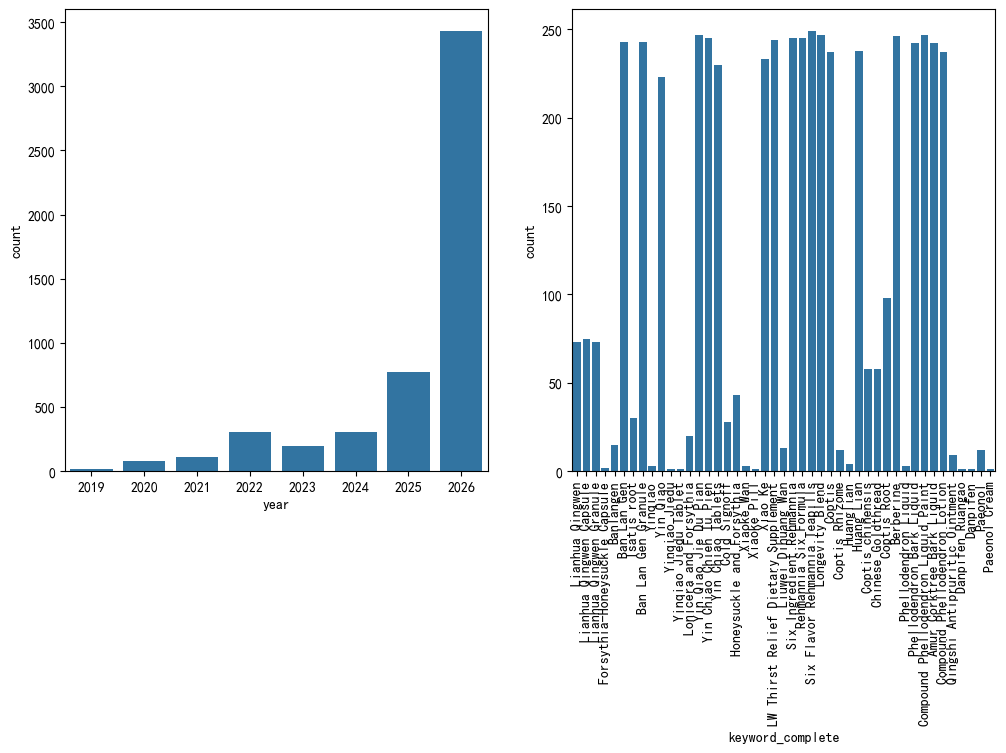

In [9]:
df = pd.read_json('data/en_TCM.jsonl', lines=True)
df['year'] = df['year'].astype(int)
fig, ax = plt.subplots(1, 2, figsize=(12,6))
sns.countplot(df, x='year', ax=ax[0])
sns.countplot(df, x='keyword_complete', ax=ax[1])
ax[1].tick_params(axis='x', rotation=90)

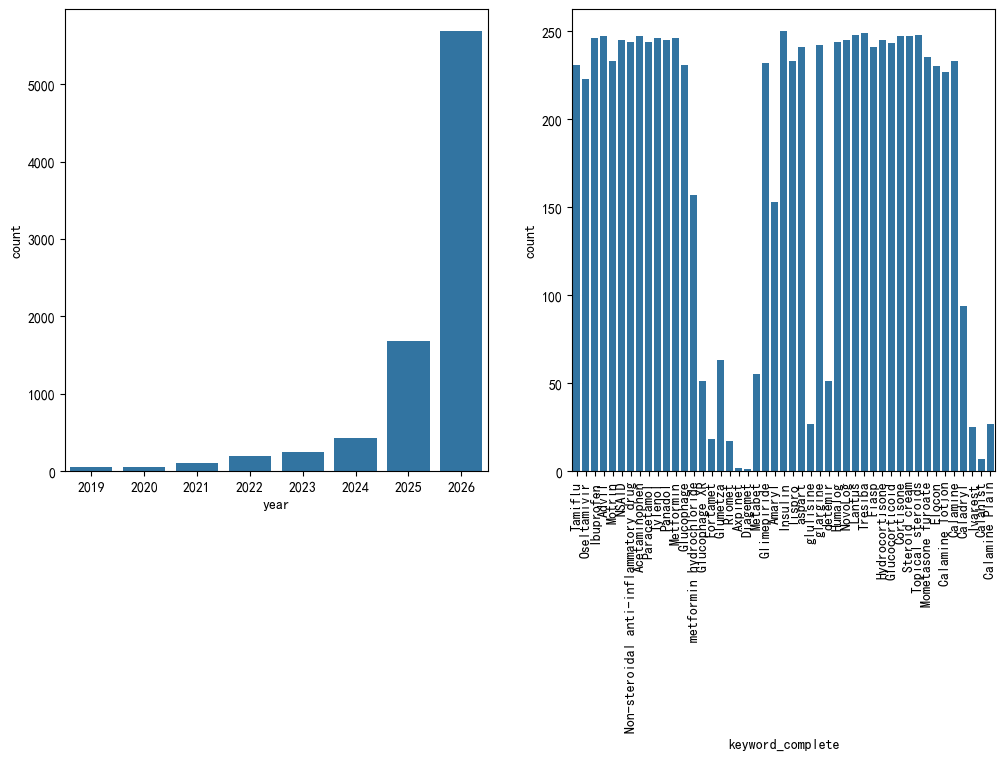

In [11]:
df = pd.read_json('data/en_EBM.jsonl', lines=True)
df['year'] = df['year'].astype(int)
fig, ax = plt.subplots(1, 2, figsize=(12,6))
sns.countplot(df, x='year', ax=ax[0])
sns.countplot(df, x='keyword_complete', ax=ax[1])
ax[1].tick_params(axis='x', rotation=90)

## Cleaning and Storage

We will track the following variables:
- content
- language
- medicine_type
- source
- search_keyword
- medicine_matches
- medicine_name
- medicine_uname
- medicine_en_uname
- medicine_category
- title
- poster
- downs
- ups
- comments_count
- shared_count
- note_id
- created_utc
- created_year
- note_url
- condition_mentioned

With more columns produced during analyses

In [350]:
en_ebm_df = pd.read_json("data/en_EBM.jsonl", lines = True)
en_tcm_df = pd.read_json("data/en_TCM.jsonl", lines = True)

In [351]:
en_df = pd.concat([en_ebm_df, en_tcm_df])
en_df.head(2)

,kind,language,medicine_type,keyword_complete,subreddit,selftext,body,author_fullname,title,downs,ups,created_utc,permalink,id,year,month,day
0,t3,en,EBM,Tamiflu,LKS_Off_Topics,"Hey guys, I’m laying in bed for the second day...",unknown,af608378c7b6cf560b40a55cfdb8b907bb00e53f7a93ea...,Anything to make the flu more bearable?,0,3,1775147748,/r/LKS_Off_Topics/comments/1sameeq/anything_to...,1sameeq,2026,4,2
1,t3,en,EBM,Tamiflu,H5N1_AvianFlu,Vietnam Plus [https://en.vietnamplus.vn/cambod...,unknown,6de47dcb7a90718bb3a530f12836eabd3b446ff6fc849c...,Cambodia reports child infected with H5N1 avia...,0,49,1774968990,/r/H5N1_AvianFlu/comments/1s8pr9n/cambodia_rep...,1s8pr9n,2026,3,31


In [352]:
# we want posts only
reddit_api_kind = {
    "t1": "Comment",
    "t2": "Account",
    "t3": "Post",
    "t4": "Message",
    "t5": "Subreddit",
    "t6": "Award"
}
en_df['kind_name'] = en_df['kind'].apply(lambda x: reddit_api_kind[x])
en_df = en_df[en_df['kind_name'] == "Post"]
en_df = en_df.drop(columns=["kind", "kind_name", "body"]) # only comments have a "body" field

In [353]:
en_df.columns

Index(['language', 'medicine_type', 'keyword_complete', 'subreddit',
       'selftext', 'author_fullname', 'title', 'downs', 'ups', 'created_utc',
       'permalink', 'id', 'year', 'month', 'day'],
      dtype='str')

In [354]:
en_df_complete = pd.DataFrame({
    "content": en_df['selftext'],
    "language": "en",
    "medicine_type": en_df['medicine_type'],
    "source": "reddit",
    "search_keyword": en_df['keyword_complete'],
    "title": en_df['title'],
    "poster": en_df['author_fullname'],
    "downs": en_df['downs'],
    "ups": en_df['ups'],
    "comments_count": UNAVAILABLE_FIELD,
    "shared_count": UNAVAILABLE_FIELD,
    "note_id": en_df['id'],
    "created_utc": en_df['created_utc'],
    "created_year": en_df['year'],
    "note_url": en_df['permalink'].apply(lambda url: f"www.reddit.com{url}")
})

In [355]:
en_keywords = keyword_flattened['en']
en_df_complete['medicine_matches'] = en_df_complete.apply(
    lambda series: ','.join(
        [keyword for keyword in en_keywords
         if keyword.lower() in str(series['content']).lower() or keyword.lower() in str(series['title']).lower()]
    ),
    axis = 1
)

### Make sure everything matches at least one keyword.<br>
This step implicitly filters for English keywords, but it is likely that a non-English post could include English drug names.

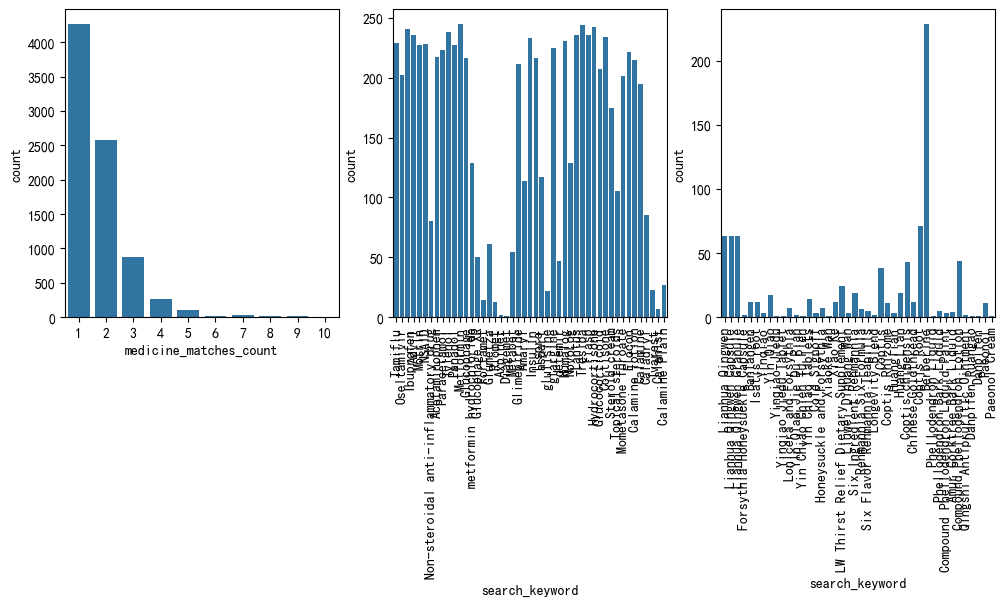

In [356]:
# empty string also returns length 1
en_df_complete['medicine_matches_count'] = en_df_complete.apply(
    lambda series: len(series['medicine_matches'].split(',')) if len(series['medicine_matches']) > 0 else 0,
    axis = 1
)
en_df_filtered_1 = en_df_complete[en_df_complete['medicine_matches_count']>0]

fig, ax = plt.subplots(1, 3, figsize=(12, 4))
sns.countplot(en_df_filtered_1, x='medicine_matches_count', ax=ax[0])
sns.countplot(en_df_filtered_1[en_df_filtered_1['medicine_type']=="EBM"], x='search_keyword', ax=ax[1])
sns.countplot(en_df_filtered_1[en_df_filtered_1['medicine_type']=="TCM"], x='search_keyword', ax=ax[2])
ax[1].tick_params(axis='x', rotation=90)
ax[2].tick_params(axis='x', rotation=90)

In [357]:
en_df_filtered_1 = en_df_filtered_1.drop(columns = 'medicine_matches_count')

In [358]:
en_df_filtered_1['medicine_unames'] = en_df_filtered_1['medicine_matches'].apply(
    lambda x: ','.join(set([uname_map[med] for med in x.split(',')]))
)

In [359]:
# since we constructed the unique names using the English keywords list, it is guaranteed to be an English uname
en_df_filtered_1['medicine_en_unames'] = en_df_filtered_1['medicine_unames']

In [360]:
en_df_filtered_1['medicine_categories'] = en_df_filtered_1['medicine_matches'].apply(
    lambda x: ','.join(set([cond_map[med] for med in x.split(',')]))
)

### Filter for posts on or after year 2019

In [361]:
en_df_filtered_1['created_year'] = en_df_filtered_1['created_year'].astype(int)
en_df_filtered_1 = en_df_filtered_1[en_df_filtered_1['created_year'] >= 2019]

username is already anonymized during scraping

In [362]:
en_df_filtered_1['note_id'] = en_df_filtered_1['note_id'].apply(lambda x: anonymize_username(x))

### Store

In [363]:
en_df_filtered_1.to_csv("../corpus/en/reddit_en_corpus_complete.csv", index=False)

### Pivot longer by matched unique name

In [93]:
en_df = pd.read_csv("../corpus/en/reddit_en_corpus_complete.csv")

In [94]:
en_df.describe()

,downs,ups,comments_count,shared_count,created_utc,created_year
count,8173.0,8173.000000,0.0,0.0,8.173000e+03,8173.000000
mean,0.0,19.187324,NaN,NaN,1.752284e+09,2025.185611
std,0.0,105.487986,NaN,NaN,4.307094e+07,1.460754
min,0.0,0.000000,NaN,NaN,1.546467e+09,2019.000000
25%,0.0,1.000000,NaN,NaN,1.754180e+09,2025.000000
50%,0.0,2.000000,NaN,NaN,1.772000e+09,2026.000000
75%,0.0,7.000000,NaN,NaN,1.774882e+09,2026.000000
max,0.0,3207.000000,NaN,NaN,1.775365e+09,2026.000000


In [95]:
en_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8173 entries, 0 to 8172
Data columns (total 19 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   content              7771 non-null   str    
 1   language             8173 non-null   str    
 2   medicine_type        8173 non-null   str    
 3   source               8173 non-null   str    
 4   search_keyword       8173 non-null   str    
 5   title                8173 non-null   str    
 6   poster               8173 non-null   str    
 7   downs                8173 non-null   int64  
 8   ups                  8173 non-null   int64  
 9   comments_count       0 non-null      float64
 10  shared_count         0 non-null      float64
 11  note_id              8173 non-null   str    
 12  created_utc          8173 non-null   int64  
 13  created_year         8173 non-null   int64  
 14  note_url             8173 non-null   str    
 15  medicine_matches     8173 non-null   str    
 16 

In [96]:
names = set([item for item, value in uname_map.items()])
for name in names:
    en_df[name] = en_df['medicine_matches'].apply(lambda x: name in x.split(','))

/tmp/ipykernel_27515/4182850349.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  en_df[name] = en_df['medicine_matches'].apply(lambda x: name in x.split(','))
/tmp/ipykernel_27515/4182850349.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  en_df[name] = en_df['medicine_matches'].apply(lambda x: name in x.split(','))
/tmp/ipykernel_27515/4182850349.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all colu

In [97]:
en_df_long = en_df.melt(
    value_vars = names,
    id_vars = set(en_df.columns) - names,
    var_name = "medicine_name"
)
en_df_long = en_df_long[en_df_long['value']].drop(columns = 'value')
en_df_long.shape

(14226, 20)

In [98]:
en_df_long['medicine_uname'] = en_df_long['medicine_name'].apply(lambda x: uname_map[x])
en_df_long['medicine_en_uname'] = en_df_long['medicine_uname'].apply(lambda x: en_uname_map[x])
en_df_long['medicine_category'] = en_df_long['medicine_en_uname'].apply(lambda x: cond_map[x])
en_df_long = en_df_long.drop(columns = ['medicine_en_unames', 'medicine_categories', 'medicine_unames'])

In [99]:
en_df_long['medicine_type'] = en_df_long['medicine_en_uname'].apply(lambda x: type_map[x])

In [100]:
en_df_long.columns

Index(['created_utc', 'comments_count', 'shared_count', 'source', 'note_url',
       'medicine_type', 'content', 'ups', 'title', 'search_keyword',
       'language', 'downs', 'created_year', 'note_id', 'poster',
       'medicine_matches', 'medicine_name', 'medicine_uname',
       'medicine_en_uname', 'medicine_category'],
      dtype='str')

In [101]:
en_df_long.head(2)

,created_utc,comments_count,shared_count,source,note_url,medicine_type,content,ups,title,search_keyword,language,downs,created_year,note_id,poster,medicine_matches,medicine_name,medicine_uname,medicine_en_uname,medicine_category
7581,1729469729,NaN,NaN,reddit,www.reddit.com/r/ChineseMedicine/comments/1g8d...,tcm,"So, I'm coming down with a cold and I wanted t...",1,Should I stop my herbs for a cold?,Yin Chiao Tablets,en,0,2024,ac2387263ac5ebdb6c7d6c330b1016869c7ce5088d3e16...,7a1a08b438a75ef75866b045b64175407379f509dedf19...,Ban Lan Gen,Ban Lan Gen,Banlangen,Banlangen,flu
25609,1772728342,NaN,NaN,reddit,www.reddit.com/r/Allergy_Immunology/comments/1...,ebm,# Understanding Samter’s Triad: When Aspirin a...,1,Understanding Samter’s Triad,Motrin,en,0,2026,cf0326e1066de65791231c78c1a1d8f2ef567f9111e5fc...,20ce9f14efa181a0c1f90e14765caa8af7af87ccef37b6...,"Ibuprofen,Advil,Motrin,NSAID,Non-steroidal ant...",Non-steroidal anti-inflammatory drug,Ibuprofen,Ibuprofen,flu


In [102]:
en_df_long[en_df_long['content'] != en_df_long['content']]

,created_utc,comments_count,shared_count,source,note_url,medicine_type,content,ups,title,search_keyword,language,downs,created_year,note_id,poster,medicine_matches,medicine_name,medicine_uname,medicine_en_uname,medicine_category
48411,1759967164,NaN,NaN,reddit,www.reddit.com/r/ChineseMedicine/comments/1o1r...,tcm,NaN,3,Systematic Differentiation of Yinqiao San &amp...,Yinqiao,en,0,2025,c10484ac9521ee13d294b2f5327183b0f416160767f64e...,cfa19d65e132c9fa8b729abb9e8b6ba34269cfa88941ee...,Yinqiao,Yinqiao,Yinqiao,Yinqiao,flu
61789,1772869613,NaN,NaN,reddit,www.reddit.com/r/Type1Diabetes/comments/1rn41q...,ebm,NaN,1,Kirsty Novolog,NovoLog,en,0,2026,512cbede8d92ddf0f1a5b5528c8cf513e482133655e7f4...,288118d7ff498d50a200d90e205b79819439ac336465fa...,NovoLog,NovoLog,Insulin,Insulin,diabetes
61795,1772475994,NaN,NaN,reddit,www.reddit.com/r/IndianBeautyBees/comments/1rj...,ebm,NaN,2,decluttering novology duo at 780 free shipping,NovoLog,en,0,2026,c95e0d7efdf89ca208502954c5ae152c41f451d9ddf480...,1a60d7ca3e43669356915dbabac75ba4829d2a79416cc5...,NovoLog,NovoLog,Insulin,Insulin,diabetes
61796,1772475927,NaN,NaN,reddit,www.reddit.com/r/makeupmadnessindia/comments/1...,ebm,NaN,2,decluttering novology duo at 780 free shipping,NovoLog,en,0,2026,4cf0fe37b771bf5d726bc5015d9161bbab76225b42d714...,1a60d7ca3e43669356915dbabac75ba4829d2a79416cc5...,NovoLog,NovoLog,Insulin,Insulin,diabetes
61797,1772475877,NaN,NaN,reddit,www.reddit.com/r/ThriftIndia/comments/1rj0r5k/...,ebm,NaN,1,decluttering novology duo at 780 free shipping,NovoLog,en,0,2026,3781835ddc90730c8fb96094f5c33a31b229ca81509a61...,1a60d7ca3e43669356915dbabac75ba4829d2a79416cc5...,NovoLog,NovoLog,Insulin,Insulin,diabetes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1146108,1775350741,NaN,NaN,reddit,www.reddit.com/r/prolife/comments/1scpzvq/oops...,ebm,NaN,24,"Oops, I said that? (Tylenol vs. abortion pill ...",Tylenol,en,0,2026,a6c2f0ff122d88c71729eb7e4716ef882b7a4fe6bd4064...,8671511e62636f4c7334eecee9b3062561c573f6b56ee9...,Tylenol,Tylenol,Acetaminophen,Acetaminophen,flu
1146149,1775307453,NaN,NaN,reddit,www.reddit.com/r/thememeryremains/comments/1sc...,ebm,NaN,384,T’was the Tylenol M’lord,Tylenol,en,0,2026,80c6386f4ddfbf1151ab01d18d08c519b709477f3f1918...,b18db9230982e5223164176ded567f33ca2b6b20aeb7ab...,Tylenol,Tylenol,Acetaminophen,Acetaminophen,flu
1146197,1775239156,NaN,NaN,reddit,www.reddit.com/r/americandad/comments/1sbktqs/...,ebm,NaN,1174,What’s your record for Tylenol PM’s?,Tylenol,en,0,2026,46875c31ae9623f1a6134aba410839335fbda495df9e43...,9faf60f9f9b1b2681884996a2100144d2e11c22aa9b6e2...,Tylenol,Tylenol,Acetaminophen,Acetaminophen,flu
1146250,1775172302,NaN,NaN,reddit,www.reddit.com/r/autismmemes/comments/1sax7cz/...,ebm,NaN,96,have a tylenol,Tylenol,en,0,2026,1ea237eb493cb8e5136bfaea7a8aed7a58f729c6cfbe3e...,1555e0172054cd8be605c1a832a9e43b42ebe5b25728da...,Tylenol,Tylenol,Acetaminophen,Acetaminophen,flu


In [103]:
en_df_long['condition_mentioned'] = en_df_long.apply(
    lambda series: (series['medicine_category'].lower() in str(series['content']).lower())
                   or (series['medicine_category'].lower() in str(series['title']).lower()),
    axis=1
)
en_df_long.shape[0], en_df_long['condition_mentioned'].sum()

(14226, np.int64(3785))

Example of posts not related to the effectiveness of the *medicine*

In [104]:
test_df = en_df_long[~en_df_long['condition_mentioned']]['content']
print(test_df[test_df.apply(lambda x: "line structure" in str(x))].iloc[0])

I've been having some major issues trying to figure out the line structure with hydrogen bonding sites identified for Oseltamivir. Our teacher only taught us how to draw simple IUPAC names into line structures. I've already figured out how to draw the Lewis Structure, but have absolutely no idea how to convert it into a line structure, no matter how many videos I try to watch on it. If anyone could help, that would be extremely appreciated.


Example of posts related to the medicine but did not mention the condition

In [105]:
test_df = en_df_long[~en_df_long['condition_mentioned']]['content']
print(test_df[test_df.apply(
    lambda x: 'coptis roots, astralagus root, Licorice Root, ginger and jujube.' in str(x)
)].iloc[0])

I went to see a licensed CM doctor for gut issue and was told my gut is weak. I told him I have history of H pylori and stomach ulcer.  He wrote a formula for me and gave me list of thing I should do, not do, what to eat and what not to eat for better effects of the medicine. The formula he wrote was meant for dealing inflammation and has antibacterial affects. I can't read his writing of the formula but I do recognize some herb. The herbs I notice was coptis roots, astralagus root, Licorice Root, ginger and jujube. I look up those ingredients and say they suppose have great effect on dealing gut inflammation and protect gut lining. So, I was looking forward that the formula would fix my problem.  After my 3rd day intake, which is today and suddenly my large intestine / colon starting to hurt.  Least I know is not appendicitis because it not up to that level of pain. My thought is, why I have this issue when the formula suppose to protect me and improve me? I follow the instructions, e

Not going to remove everything not mentioning the condition for now

### Language identification
[FastText](https://fasttext.cc/docs/en/language-identification.html)

In [106]:
# !pip install fasttext
model = fasttext.load_model('lid.176.ftz')

In [107]:
title_class = model.predict(
    en_df_long['title'].apply(lambda x: x.replace("\n", " ") if x == x else "").to_list()
)
content_class = model.predict(
    en_df_long['content'].apply(lambda x: x.replace("\n", " ") if x == x else "").to_list()
)

In [108]:
def parse_prediction(pred):
    label = [langs[0].replace("__label__", "") for langs in pred[0]]
    conf = [confs[0] for confs in pred[1]]
    return pd.DataFrame({"language": label, "confidence": conf})

In [109]:
title_pred = parse_prediction(title_class).rename(columns = {"language": "title_language", "confidence": "title_language_confidence"})
content_pred = parse_prediction(content_class).rename(columns = {"language": "content_language", "confidence": "content_language_confidence"})

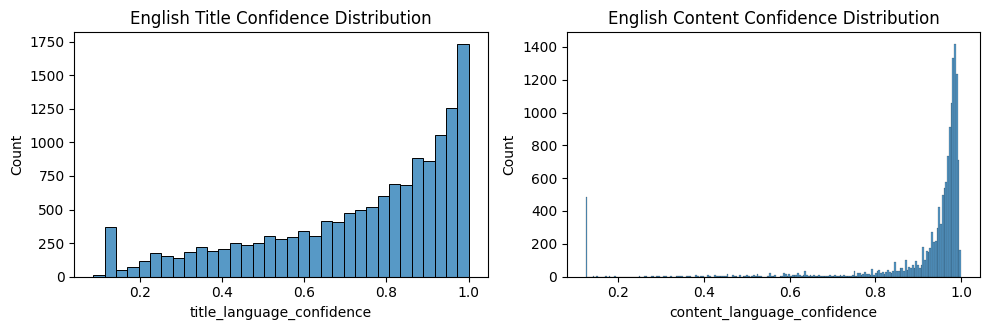

In [112]:
set_plot_english()
fig, ax = plt.subplots(1, 2, figsize=(10,3.4))
sns.histplot(title_pred, x='title_language_confidence', ax=ax[0])
ax[0].set_title("English Title Confidence Distribution")
sns.histplot(content_pred, x='content_language_confidence', ax=ax[1])
ax[1].set_title("English Content Confidence Distribution")
plt.tight_layout()
fig.savefig("plots/english_conf.png", dpi=300)

In [114]:
en_df_long_filtered = pd.concat([
    en_df_long.reset_index(drop=True),
    title_pred,
    content_pred
], axis=1)

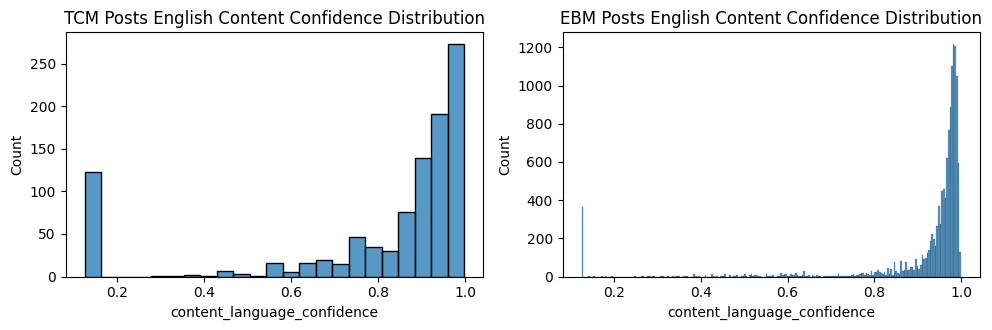

In [117]:
fig, ax = plt.subplots(1, 2, figsize=(10,3.4))
sns.histplot(
    en_df_long_filtered[en_df_long_filtered['medicine_type'] == 'tcm'],
    x='content_language_confidence',
    ax=ax[0]
)
ax[0].set_title("TCM Posts English Content Confidence Distribution")
sns.histplot(
    en_df_long_filtered[en_df_long_filtered['medicine_type'] == 'ebm'],
    x='content_language_confidence',
    ax=ax[1]
)
ax[1].set_title("EBM Posts English Content Confidence Distribution")
plt.tight_layout()
fig.savefig("plots/english_conf_by_med_type.png", dpi=300)

In [74]:
# accept either good prediction of English or pd.NA
# title is too short for a good prediction. Only look at title if content is pd.NA
en_mask = (
    (en_df_long_filtered['content_language']=="en") & (en_df_long_filtered['content_language_confidence']>EN_LANGUAGE_CONF_CUTOFF)
    | (
        (en_df_long_filtered['content']!=en_df_long_filtered['content']) &
        (en_df_long_filtered['title_language']=="en") & (en_df_long_filtered['title_language_confidence']>EN_LANGUAGE_CONF_CUTOFF)
    )
)
en_df_long_filtered[~en_mask][['title', 'content', 'title_language', 'title_language_confidence', 'content_language', 'content_language_confidence']]

,title,content,title_language,title_language_confidence,content_language,content_language_confidence
53,"Proposta di Struttura del Libro Scientifico: ""...",\n📚 Proposta di Struttura del Libro Scientific...,it,0.865759,it,0.972775
66,more ibuprofen!,NaN,en,0.326441,en,0.124504
78,Ibuprofen? (GlaciaCherry),NaN,en,0.219139,en,0.124504
131,13 Monate: Viel Trinken nachts &amp; häufiges ...,"Liebe Mamas,\n\nich wollte mal nach euren Erfa...",de,0.890733,de,0.996356
169,Wurzelbehandlung plus Erkältung,"Hallo,\n\nIch hatte Dienstag eine Wurzelbehand...",de,0.855273,de,0.999249
...,...,...,...,...,...,...
13854,Điều trị đái tháo đường bằng thuốc như thế nào?,NGUYÊN TẮC ĐIỀU TRỊ\n\nKiểm soát glucose huyế...,vi,0.995546,vi,0.994011
13874,Wrong insulin pen,how grave is this mistake? they gave us the wr...,en,0.828032,tl,0.293624
13905,Insulinska terapija,"Pozdrav narode,\n\nApel vama koji poznajete di...",sh,0.189341,sr,0.534067
14051,Quote,\n\n|Name|QTY|Expiration Date|\n|:-|:-|:-|\n|C...,en,0.460083,en,0.290879


In [75]:
en_df_long_filtered = en_df_long_filtered[en_mask]

### Store Final Cleaned Data

In [76]:
en_df_long_filtered.to_csv("../corpus/en/reddit_en_corpus_by_name.csv", index=False)

In [40]:
en_df_long_filtered = pd.read_csv("../corpus/en/reddit_en_corpus_by_name.csv")

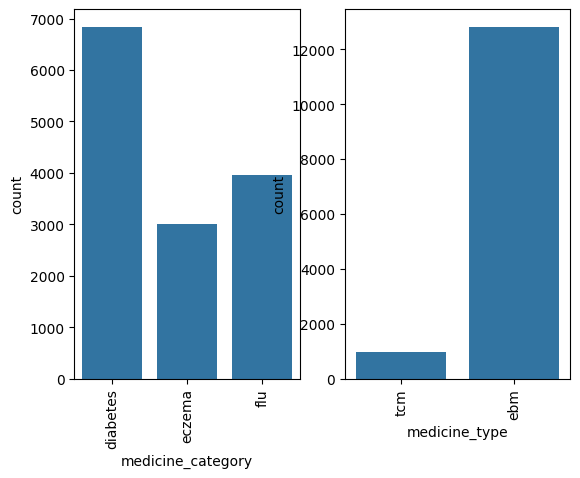

In [41]:
fig, ax = plt.subplots(1, 2)
sns.countplot(en_df_long_filtered, x='medicine_category', ax=ax[0])
sns.countplot(en_df_long_filtered, x='medicine_type', ax=ax[1])
ax[0].tick_params(axis='x', rotation=90)
ax[1].tick_params(axis='x', rotation=90)

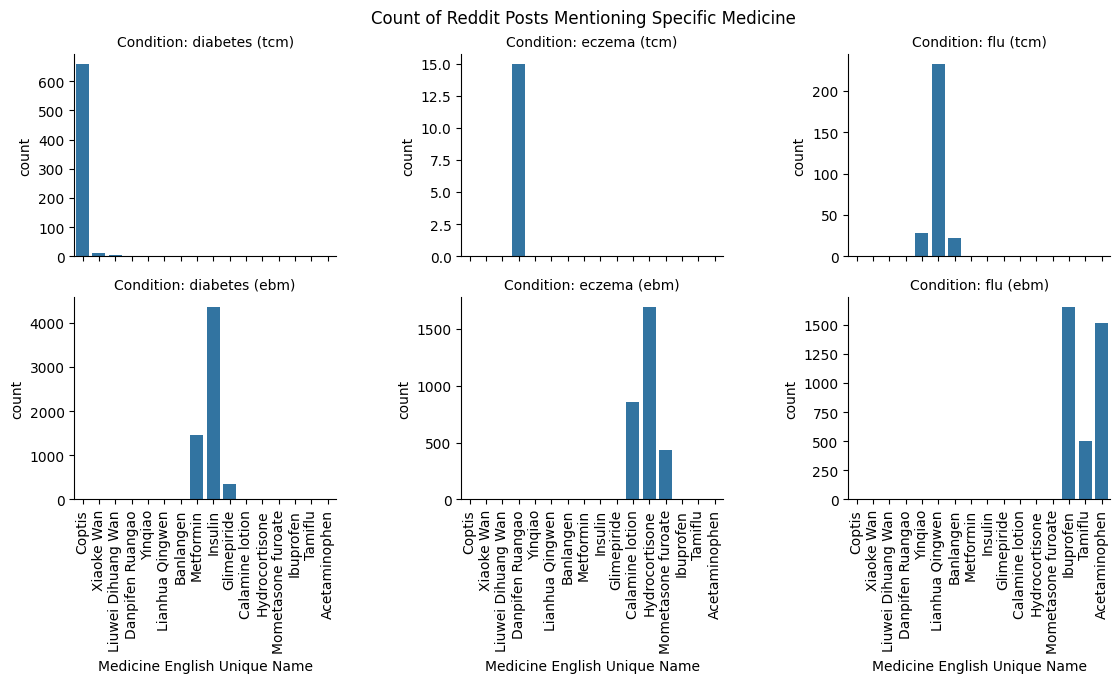

In [42]:
g = sns.FacetGrid(en_df_long_filtered, row = "medicine_type", col = "medicine_category", height=2.8, aspect=1.4, sharey=False)
g.map_dataframe(sns.countplot, x="medicine_en_uname")
g.fig.tight_layout()
labels = en_df_long_filtered['medicine_en_uname'].unique()
g.set(xticks=labels)
g.set_xticklabels(labels, rotation=90)
g.fig.subplots_adjust(top=0.9) 
g.fig.suptitle("Count of Reddit Posts Mentioning Specific Medicine")
g.set_titles("Condition: {col_name} ({row_name})")
g.set_xlabels("Medicine English Unique Name")
g.savefig("plots/en_count.png", dpi=310)

# Scrape Weibo for Chinese posts

Scraping is performed with the open-source software [MediaCrawler](https://github.com/NanmiCoder/MediaCrawler), by running `uv run main.py --platform wb --lt qrcode --type search --save_data_option sqlite` with the configurations in `MediaCrawler/config/base_config.py`.<br>
The results are stored under `MediaCrawler/database/sqlite_tables.db`<br>
To perform this scraping by yourself, follow the [installation and database initialization directions](https://github.com/NanmiCoder/MediaCrawler) provided by the publisher. Note: you will need a Sina Weibo account. This scraping takes around 24 hours to complete.

In [79]:
import matplotlib as mpl
print(mpl.get_cachedir())

/home/reptiman/.cache/matplotlib


In [159]:
with open("scrape_keywords/medicine_flattened.json") as f:
    text = json.loads(f.read())
text = ",".join(text['cn'])
with open("scrape_keywords/cn_keywords_string.txt", "w") as f:
    f.write(text)

In [160]:
conn = sqlite3.connect('../MediaCrawler/database/sqlite_tables.db')
cursor = conn.cursor()
cursor.execute("SELECT name FROM sqlite_master WHERE type='table';")
tables = cursor.fetchall()
for table in tables:
    print(table[0])
conn.close()

bilibili_video
bilibili_video_comment
bilibili_up_info
bilibili_contact_info
bilibili_up_dynamic
douyin_aweme
douyin_aweme_comment
dy_creator
kuaishou_video
kuaishou_video_comment
weibo_note
weibo_note_comment
weibo_creator
xhs_creator
xhs_note
xhs_note_comment
tieba_note
tieba_comment
tieba_creator
zhihu_content
zhihu_comment
zhihu_creator


In [161]:
conn = sqlite3.connect('../MediaCrawler/database/sqlite_tables.db')
df = pd.read_sql_query("SELECT * FROM weibo_note", conn)
conn.close()
df.shape

(23139, 18)

In [162]:
df.head(2)

,id,user_id,nickname,avatar,gender,profile_url,ip_location,add_ts,last_modify_ts,note_id,content,create_time,create_date_time,liked_count,comments_count,shared_count,note_url,source_keyword
0,1,2789987841,学霸课长,https://tvax1.sinaimg.cn/crop.0.0.512.512.180/...,m,https://m.weibo.cn/u/2789987841?luicode=200000...,北京,1775404363293,1775410147641,5283640696638754,&quot;感冒第一天，连花清瘟在身边&quot;，这不仅是一句健康主张，更是连花清瘟携手学...,1775230370,2026-04-03 15:32:50+08:00,607,175,108,https://m.weibo.cn/detail/5283640696638754,连花清瘟
1,2,1704544512,半岛网,https://tvax4.sinaimg.cn/crop.0.0.487.487.180/...,m,https://m.weibo.cn/u/1704544512?luicode=200000...,,1775404363306,1775418561034,5228088947378650,【#世界流感日# 一支视频看懂流感防治知识点】😷先划重点：流感不是普通感冒！它是流感病毒引发...,1761985801,2025-11-01 08:30:01+08:00,857,28,32,https://m.weibo.cn/detail/5228088947378650,连花清瘟胶囊


(22213, 19)


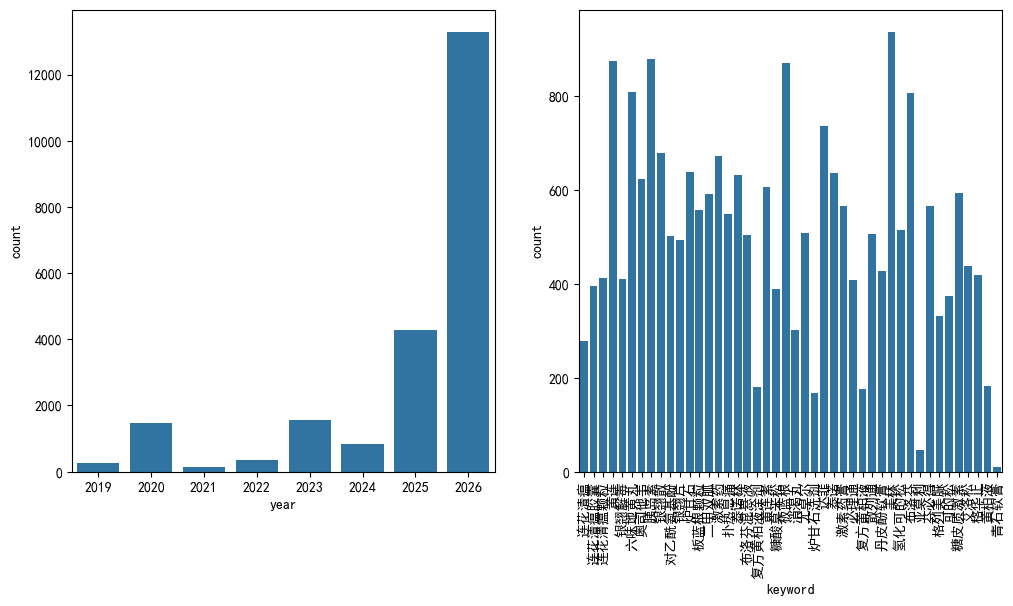

In [ ]:
set_plot_chinese()
df['year'] = df['create_date_time'].apply(lambda x: x[:4]).astype(int)
df = df[df['year'] >= 2019]
print(df.shape)
df['keyword'] = df['source_keyword']#.apply(lambda x: name_map.get(x))
fig, ax = plt.subplots(1, 2, figsize=(12,6))
sns.countplot(df, x='year', ax=ax[0])
sns.countplot(df, x='keyword', ax=ax[1])
ax[1].tick_params(axis='x', rotation=90)

## Clean and Storage

In [63]:
conn = sqlite3.connect('../MediaCrawler/database/sqlite_tables.db')
cn_df = pd.read_sql_query("SELECT * FROM weibo_note", conn)
conn.close()

In [64]:
cn_df.columns

Index(['id', 'user_id', 'nickname', 'avatar', 'gender', 'profile_url',
       'ip_location', 'add_ts', 'last_modify_ts', 'note_id', 'content',
       'create_time', 'create_date_time', 'liked_count', 'comments_count',
       'shared_count', 'note_url', 'source_keyword'],
      dtype='str')

In [67]:
cn_df_complete = pd.DataFrame({
    "content": cn_df['content'],
    "language": 'zh',
    "source": "weibo",
    "search_keyword": cn_df['source_keyword'],
    "title": UNAVAILABLE_FIELD,
    "poster": cn_df['user_id'].apply(lambda id: anonymize_username(id)),
    "downs": UNAVAILABLE_FIELD,
    "ups": cn_df['liked_count'],
    "comments_count": cn_df['comments_count'],
    "shared_count": cn_df['shared_count'],
    "note_id": cn_df['note_id'].astype(str).apply(lambda id: anonymize_username(id)),
    "created_utc": cn_df['create_time'],
    "created_year": cn_df['create_time'].apply(lambda x: datetime.fromtimestamp(x).year),
    "note_url": cn_df['note_url']
})

In [41]:
# chinese characters do not need to be lowercased
cn_keywords = keyword_flattened['cn']
cn_df_complete['medicine_matches'] = cn_df_complete.apply(
    lambda series: ','.join(
        [keyword for keyword in cn_keywords if keyword in series['content']]
    ),
    axis = 1
)

### Make sure everything matches at least one keyword.<br>

<Axes: xlabel='medicine_matches_count', ylabel='count'>

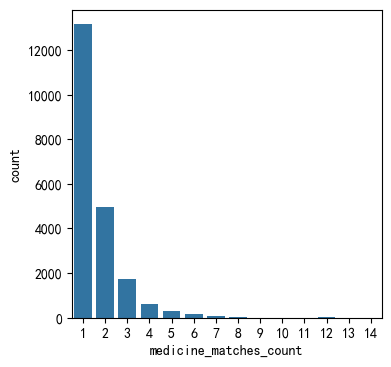

In [42]:
# empty string also returns length 1
cn_df_complete['medicine_matches_count'] = cn_df_complete.apply(
    lambda series: len(series['medicine_matches'].split(',')) if len(series['medicine_matches']) > 0 else 0,
    axis = 1
)
cn_df_filtered_1 = cn_df_complete[cn_df_complete['medicine_matches_count']>0]

fig, ax = plt.subplots(figsize=(4, 4))
sns.countplot(cn_df_filtered_1, x='medicine_matches_count', ax=ax)

In [43]:
cn_df_filtered_1 = cn_df_filtered_1.drop(columns = 'medicine_matches_count')

In [44]:
cn_df_filtered_1['medicine_unames'] = cn_df_filtered_1['medicine_matches'].apply(
    lambda x: ','.join(set([uname_map[med] for med in x.split(',')]))
)

In [45]:
cn_df_filtered_1['medicine_en_unames'] = cn_df_filtered_1['medicine_unames'].apply(
    lambda x: ','.join([en_uname_map[name] for name in x.split(',')])
)

In [46]:
cn_df_filtered_1['medicine_categories'] = cn_df_filtered_1['medicine_matches'].apply(
    lambda x: ','.join(set([cond_map[med] for med in x.split(',')]))
)

### Filter for posts on or after year 2019

In [47]:
cn_df_filtered_1['created_year'] = cn_df_filtered_1['created_year'].astype(int)
cn_df_filtered_1 = cn_df_filtered_1[cn_df_filtered_1['created_year'] >= 2019]

### Store

In [48]:
cn_df_filtered_1.to_csv("../corpus/cn/weibo_cn_corpus_complete.csv", index=False)

### Pivot longer by matched unique name

In [68]:
cn_df = pd.read_csv("../corpus/cn/weibo_cn_corpus_complete.csv")

In [69]:
cn_df.describe()

,title,downs,ups,comments_count,shared_count,created_utc,created_year
count,0.0,0.0,20101.000000,20101.000000,20101.000000,2.010100e+04,20101.000000
mean,NaN,NaN,110.244416,11.502264,26.355107,1.743100e+09,2024.857022
std,NaN,NaN,2068.747283,91.857088,361.577098,5.536380e+07,1.856133
min,NaN,NaN,0.000000,0.000000,0.000000,1.547074e+09,2019.000000
25%,NaN,NaN,0.000000,0.000000,0.000000,1.744377e+09,2025.000000
50%,NaN,NaN,1.000000,0.000000,0.000000,1.769632e+09,2026.000000
75%,NaN,NaN,6.000000,3.000000,1.000000,1.774262e+09,2026.000000
max,NaN,NaN,230950.000000,3864.000000,24187.000000,1.775520e+09,2026.000000


In [70]:
cn_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20101 entries, 0 to 20100
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   content              20101 non-null  str    
 1   language             20101 non-null  str    
 2   source               20101 non-null  str    
 3   search_keyword       20101 non-null  str    
 4   title                0 non-null      float64
 5   poster               20101 non-null  str    
 6   downs                0 non-null      float64
 7   ups                  20101 non-null  int64  
 8   comments_count       20101 non-null  int64  
 9   shared_count         20101 non-null  int64  
 10  note_id              20101 non-null  str    
 11  created_utc          20101 non-null  int64  
 12  created_year         20101 non-null  int64  
 13  note_url             20101 non-null  str    
 14  medicine_matches     20101 non-null  str    
 15  medicine_unames      20101 non-null  str    
 1

In [78]:
names = set([item for item, value in uname_map.items()])
for name in names:
    cn_df[name] = cn_df['medicine_matches'].apply(lambda x: name in x.split(','))

/tmp/ipykernel_27515/2400587842.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  cn_df[name] = cn_df['medicine_matches'].apply(lambda x: name in x.split(','))
/tmp/ipykernel_27515/2400587842.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  cn_df[name] = cn_df['medicine_matches'].apply(lambda x: name in x.split(','))
/tmp/ipykernel_27515/2400587842.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all colu

In [79]:
cn_df_long = cn_df.melt(
    value_vars = names,
    id_vars = set(cn_df.columns) - names,
    var_name = "medicine_name"
)
cn_df_long = cn_df_long[cn_df_long['value']].drop(columns = 'value')
cn_df_long.shape

(32484, 19)

In [80]:
cn_df_long['medicine_uname'] = cn_df_long['medicine_name'].apply(lambda x: uname_map[x])
cn_df_long['medicine_en_uname'] = cn_df_long['medicine_uname'].apply(lambda x: en_uname_map[x])
cn_df_long['medicine_category'] = cn_df_long['medicine_en_uname'].apply(lambda x: cond_map[x])
cn_df_long = cn_df_long.drop(columns = ['medicine_en_unames', 'medicine_categories', 'medicine_unames'])

In [81]:
cn_df_long['medicine_type'] = cn_df_long['medicine_en_uname'].apply(lambda x: type_map[x])

In [82]:
cn_df_long.columns

Index(['note_id', 'search_keyword', 'created_utc', 'content', 'shared_count',
       'ups', 'comments_count', 'language', 'title', 'source', 'downs',
       'poster', 'note_url', 'created_year', 'medicine_matches',
       'medicine_name', 'medicine_uname', 'medicine_en_uname',
       'medicine_category', 'medicine_type'],
      dtype='str')

In [83]:
cn_df_long['medicine_category_cn'] = cn_df_long['medicine_category'].apply(lambda x: medicine_category_cn[x])
cn_df_long['condition_mentioned'] = cn_df_long.apply(
    lambda series: (series['medicine_category_cn'] in str(series['content']))
                   or (series['medicine_category_cn'] in str(series['title'])),
    axis=1
)
cn_df_long = cn_df_long.drop(columns = 'medicine_category_cn')
cn_df_long.shape[0], cn_df_long['condition_mentioned'].sum()

(32484, np.int64(6725))

### Language identification
[FastText](https://fasttext.cc/docs/en/language-identification.html)

In [84]:
model = fasttext.load_model('lid.176.ftz')

In [85]:
# we do not get titles for Weibo posts
content_class = model.predict(
    cn_df_long['content'].apply(lambda x: x.replace("\n", " ") if x == x else "").to_list()
)

In [86]:
def parse_prediction(pred):
    label = [langs[0].replace("__label__", "") for langs in pred[0]]
    conf = [confs[0] for confs in pred[1]]
    return pd.DataFrame({"language": label, "confidence": conf})

In [87]:
content_pred = parse_prediction(content_class).rename(columns = {"language": "content_language", "confidence": "content_language_confidence"})

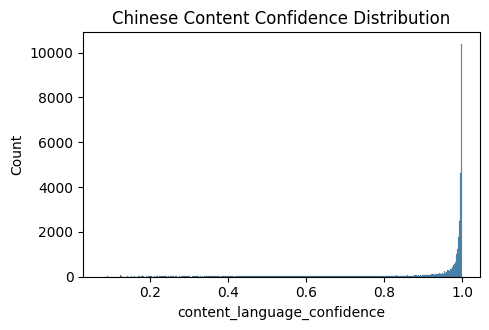

In [92]:
set_plot_english()
fig, ax = plt.subplots(figsize=(5,3.4))
sns.histplot(content_pred, x='content_language_confidence', ax=ax)
ax.set_title("Chinese Content Confidence Distribution")
plt.tight_layout()
fig.savefig("plots/chinese_conf.png", dpi=300)

In [64]:
cn_df_long_filtered = pd.concat([cn_df_long.reset_index(drop=True), content_pred], axis=1)

In [66]:
cn_mask = (
    (cn_df_long_filtered['content_language']=="zh") & (cn_df_long_filtered['content_language_confidence']>CN_LANGUAGE_CONF_CUTOFF)
)
print(cn_df_long_filtered[~cn_mask].shape)
cn_df_long_filtered[~cn_mask].head()[['content', 'content_language', 'content_language_confidence']]

(1551, 23)


,content,content_language,content_language_confidence
14,#家庭用药# 120个家庭常用中成药，建议收藏，以备不时之需。1. 桂枝合剂—感冒风寒表虚证...,ja,0.409968
19,jīn yín huā 金 银 花国涛医药：名医名药清热解毒，消炎退肿。别名：忍冬花，鹭鸳花...,ja,0.769064
27,图中中药公司的核心产品涵盖特一药业止咳宝片、汉森制药四磨汤口服液、生物谷灯盏生脉胶囊、恩威医...,ja,0.513291
52,临床汤剂化载，中成药选用表！（家庭必备）肝肾不足--------六味地黄丸、龙牡壮骨冲剂心血...,zh,0.090432
67,病人耳朵里热疼，手放耳朵上都能感觉到热气脉有力，考虑风热感冒，用银翘散；脉无力，考虑肾阴虚，...,ja,0.553783


In [67]:
cn_df_long_filtered = cn_df_long_filtered[cn_mask]

### Store Final Cleaned Data

In [68]:
cn_df_long_filtered.to_csv("../corpus/cn/weibo_cn_corpus_by_name.csv", index=False)

In [43]:
cn_df_long_filtered = pd.read_csv("../corpus/cn/weibo_cn_corpus_by_name.csv")

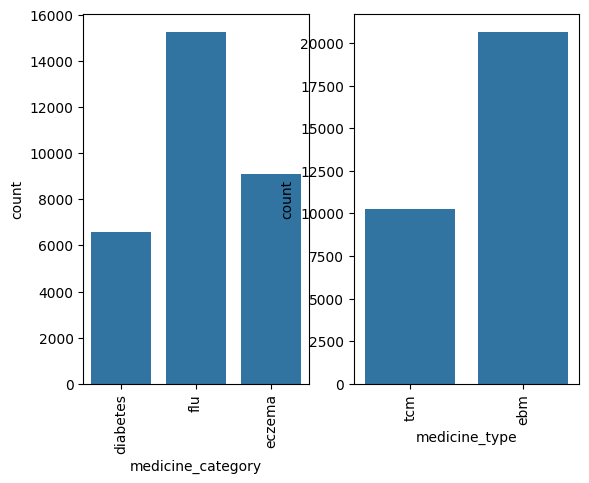

In [44]:
fig, ax = plt.subplots(1, 2)
sns.countplot(cn_df_long_filtered, x='medicine_category', ax=ax[0])
sns.countplot(cn_df_long_filtered, x='medicine_type', ax=ax[1])
ax[0].tick_params(axis='x', rotation=90)
ax[1].tick_params(axis='x', rotation=90)

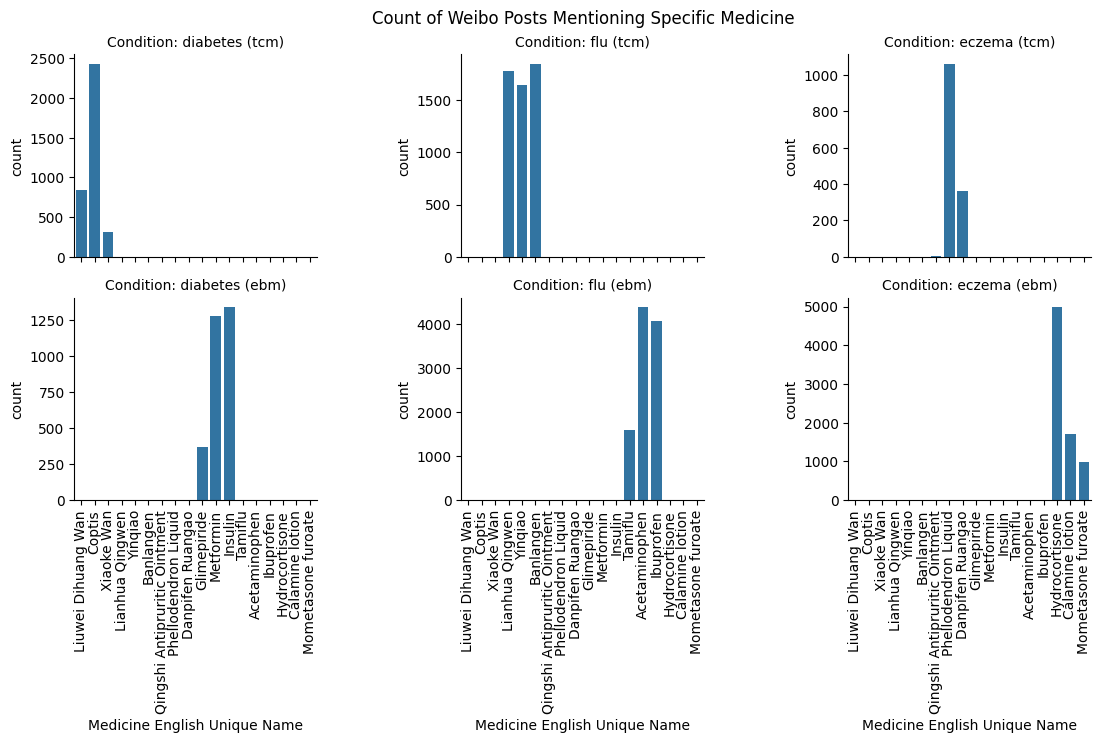

In [ ]:
set_plot_english()
g = sns.FacetGrid(cn_df_long_filtered, row = "medicine_type", col = "medicine_category", height=2.8, aspect=1.4, sharey=False)
g.map_dataframe(sns.countplot, x="medicine_en_uname")
g.fig.tight_layout()
labels = cn_df_long_filtered['medicine_en_uname'].unique()
g.set(xticks=labels)
g.set_xticklabels(labels, rotation=90)
g.fig.subplots_adjust(top=0.9) 
g.fig.suptitle("Count of Weibo Posts Mentioning Specific Medicine")
g.set_titles("Condition: {col_name} ({row_name})")
g.set_xlabels("Medicine English Unique Name")
g.savefig("plots/cn_count.png", dpi=310)

# Combine dataframes

In [39]:
cn_df = pd.read_csv("../corpus/cn/weibo_cn_corpus_by_name.csv")
en_df = pd.read_csv("../corpus/en/reddit_en_corpus_by_name.csv")
df = pd.concat([cn_df, en_df])
df.head(2)

,note_url,ups,note_id,downs,search_keyword,poster,content,created_year,title,created_utc,...,medicine_name,medicine_uname,medicine_en_uname,medicine_category,medicine_type,condition_mentioned,content_language,content_language_confidence,title_language,title_language_confidence
0,https://m.weibo.cn/detail/5284369541104040,12,5089dadbcaf1730ece14e743f2c1865f7060f88e2c6245...,NaN,黄连,1f299bdafa9bac6ad65f66919c24589b66c02711139ffc...,中医常用15种中成药，不贵好用，男女都能用，建议收藏备用！现在很多人，遇到小毛病不想去医院排...,2026,NaN,1775404140,...,六味地黄丸,六味地黄丸,Liuwei Dihuang Wan,diabetes,tcm,True,zh,0.936954,NaN,NaN
1,https://m.weibo.cn/detail/5283961733646759,0,400b38866b98dc3e22933bf0af096f4b3e9b560c129ed2...,NaN,六味地黄丸,3ee54452a8a31e46ee48840ef028933bb15ec10b8dba4f...,中国地标中成药一、4 大直辖市：京派与海派精粹1.北京：同仁堂安宫牛黄丸、大山楂丸。源自宫廷...,2026,NaN,1775306911,...,六味地黄丸,六味地黄丸,Liuwei Dihuang Wan,diabetes,tcm,False,zh,0.962145,NaN,NaN


In [46]:
# Create unique index for each entry
df = df.reset_index(drop=True).reset_index().rename(columns = {'index': 'id'})

In [47]:
df.to_csv("../corpus/combined/combined_corpus_by_name.csv", index=False)

In [48]:
df = pd.read_csv("../corpus/combined/combined_corpus_by_name.csv")

## Get rid of unrelated entries

In [49]:
df[df['language']=='zh'].shape[0], df[df['language']=='en'].shape[0]

(30933, 13796)

In [50]:
# dummy standin
related = np.zeros(shape = df.shape[0])

In [51]:
X_train, X_test, y_train, y_test = train_test_split(
    df, related, train_size=0.01, stratify=df["language"], random_state=42
)

In [52]:
X_train.shape

(447, 26)

In [55]:
X_train[['id', 'title', 'content', 'medicine_name', 'condition_mentioned']].to_csv('../corpus/combined/train_set.csv', index=False)

In [56]:
X_train.to_csv('../corpus/combined/train_set_complete.csv', index=False)

In [57]:
X_test.to_csv('../corpus/combined/test_set_complete.csv', index=False)

## Manually annotate them as related or not

**Inclusion Criteria:** Anything remotely related to the medicine being used as a treatment for some human conditions
<br><br>
**Exclusion Criteria:**
- Clinical/Physiology/Chemistry Studies (not patient perspective)
- Drug Price/Industry/Stock Price
- Manufacturing Procedures
- Veterinary Cases

In [13]:
annotated = pd.read_csv("../corpus/combined/train_set_annot.csv")
annotated['related'] = annotated['related'].astype(bool)
annotated.head(2)

,id,title,content,medicine_name,condition_mentioned,related
0,34344,Can I vent about doctors and prescriptions for...,**EDIT**: I want to clarify that when I was wr...,Insulin,False,True
1,39315,pKa mnemonic,"OH is always trying to snatch hydrogens, but i...",aspart,False,False


In [14]:
sum(annotated['related']), annotated.shape[0] - sum(annotated['related'])

(358, 89)

In [15]:
annotated[~annotated['related']].sample(5)

,id,title,content,medicine_name,condition_mentioned,related
202,11805,NaN,患者因为2019年的眼部疾病，在某大学附属医院进行眼科手术，手术后医生给患者用了激素控制炎症...,可的松,False,False
283,20837,NaN,TUDCA 不仅仅可以保护肝脏和胆囊，还可以通过改善脂肪消化来帮助脂肪吸收，但它也能选择性地...,胰岛素,True,False
360,2893,NaN,业绩爆发！10家高增长创新药龙头（精简版） 1. 通化东宝（600867）：净利**+300...,连花清瘟,False,False
418,879,NaN,#庄达菲# #我的刺猬女孩# #白月光# 后天的哥斯拉的微博视频,达菲,False,False
348,21528,NaN,最容易升高血糖的5种药物：1，糖皮质激素（GC）论升糖能力，糖皮质激素堪排第一，一方面，GC...,胰岛素,True,False


In [16]:
annotated_full = pd.read_csv("../corpus/combined/train_set_complete.csv")
annotated_full = annotated_full.merge(annotated[['id', 'related']], on='id')

## Encoding
[HuggingFace](https://huggingface.co/docs/transformers/en/index) <br>
[xlm-roberta-base](https://huggingface.co/FacebookAI/xlm-roberta-base)

***The following training are performed on Google Colab with GPU.***<br>
***Note the different relative paths, accessing files in Google Drive.***

In [9]:
annotated = pd.read_csv("train_set_annot.csv")
annotated['related'] = annotated['related'].astype(bool)
annotated_full = pd.read_csv("train_set_complete.csv")
annotated_full = annotated_full.merge(annotated[['id', 'related']], on='id')

In [5]:
from huggingface_hub import notebook_login
notebook_login()

In [6]:
tokenizer = AutoTokenizer.from_pretrained("xlm-roberta-base")
model = AutoModel.from_pretrained("xlm-roberta-base")
print(tokenizer._tokenizer.normalizer)
print(tokenizer._tokenizer.pre_tokenizer)
print(tokenizer._tokenizer.model)
print(tokenizer._tokenizer.decoder)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

XLMRobertaModel LOAD REPORT from: xlm-roberta-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Sequence(normalizers=[Strip(strip_left=False, strip_right=True), Replace(pattern=String(" {2,}"), content="▁")])
Sequence(pretokenizers=[WhitespaceSplit(), Metaspace(replacement="▁", prepend_scheme=always, split=True)])
Unigram(unk_id=3, vocab=[("<s>", 0), ("<pad>", 0), ("</s>", 0), ("<unk>", 0), (",", -3.4635426998138428), ...], byte_fallback=False)
Metaspace(replacement="▁", prepend_scheme=always, split=True)


In [7]:
print(tokenizer.special_tokens_map)

{'bos_token': '<s>', 'eos_token': '</s>', 'unk_token': '<unk>', 'sep_token': '</s>', 'pad_token': '<pad>', 'cls_token': '<s>', 'mask_token': '<mask>'}


In [10]:
with pd.option_context('display.max_colwidth', None, 'display.max_rows', None):
    display(annotated_full.iloc[0][['title', 'content', 'medicine_name']])

title                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                           

In [11]:
test = f"""Insulin </s></s> Can I vent about doctors and prescriptions for a sec? </s></s> **EDIT**: I want to clarify that when I was writing this I was really fresh off this and missed an important detail: For my insurance, they seem to be okay with swapping name brands and generics at the pharmacy. What they don't like is swapping biosimilars for name brands, and that's what's causing a lot of these problems. I use the terms interchangeably a lot but in all cases I definitely mean "biosimilar".\n\nOy vey, I'm having a day. \n\nBeen T1 for like, 30 years at this point. Been on Lantus for close to 20 of those years. I've had some ups and downs with medical professionals and pharmacies and the like but this current one might just take the cake because the problem is coming from the source.\n\nIt's October. Time of year when my prescriptions lapse and need to be refilled. CVS does the thing they do and reaches out for renewal. I think nothing of anything going on because hey, never had an issue with this process before. Until I get a notification: "Rx TRE is ready."\n\nHuh. What. That doesn't sound like any insulin I take. I open the app. It's for Tresiba. What? I also see another prescription for "insulin glargine yfcn". Some of you can probably spot what happened right here but for those who didn't...\n\nCVS says that's what my doctor sent, so I fire up good 'ol mychart and fire off a message to my doctor...who's out of office until next year so the message goes to the care team for handling. That's fine, whatever, they usually handle prescription stuff anyway. In the interim I go to pick up the Tresiba...and it's in vial form. Great. Sigh. (I usually take pens.)\n\nI hear back from my doctor's team and they're now swearing up and down that they were told by CVS that Lantus isn't covered anymore. Which is weird, because I'm on Medicare Part D, and usually those plans 1. don't change significantly mid-year, and 2. will notify you if one of your medications is getting dropped and what they suggest you switch to. (Case in point...I got a notification that my Humalog is getting dropped in 2026 like a month ago.)\n\nI got no such notification. So I replied saying "hey, I'm willing to try the Tresiba because it seems like it might be an improvement buuuuuut can you double check your work because I think there was a communication breakdown somewhere, far as I know, Lantus is still covered. Also hey can you send a prescription for syringes so I can take the Tresiba I got?" They thankfully got THAT prescription in fast.\n\nAnyway, last night I did some deeper digging and figured it out: My doctor's office sent for generic/biosimilar glargine, NOT actual Lantus. Which I guessed might have tripped up things. I decided to wait until today so I could speak with the pharmacist as I picked up my syringes.\n\nBetween then and now, I got another message from my doctor's care team, stating bluntly: "I spoke with them. Lantus is no longer covered. Tresiba is the alternative." (Who's them?)\n\nUpon picking up the syringes, the pharmacist confirmed that yep, we're just following orders, your doctor's the one who sent for biosimilar glargine, not us. And it indeed isn't covered by your plan and unless some significant mid-cycle change occurred, your Lantus should still be covered. Try getting them to send a corrected prescription, that should fix this.\n\nI get home, quite incensed at this point (not at the pharmacist, of course), am in "You Are Wrong And I Am Going To Prove It" mode, so I bust out the abridged formulary that's been sitting in my documents box for the last year, AND consult Cigna's website just in case the formulary was updated. (It was not.)\n\nHey, what's that?\n\n*What do we see? Right there? Page 32? Under "L"?*\n\nGASP. It can't be.\n\n***LANTUS SOLOSTAR U-100 INSULIN, TIER 3***\n\nNot covered my ***arse.***\n\nGuess what isn't in any of the formularies?\n\nSemglee/glargine-yfcn.\n\nIt sure looks like my doctor's team is trying to ram through a generic and not understanding (despite me pointing it out ***TWICE*** now) that my plan doesn't cover the generic.\n\nI think the insult to injury here is that prescription of Tresiba they gave me? Yeah, it's only for one vial a month with the dosage they put on it. Yay.\n\nThis whole thing has made me want to slam my head into a desk, and go figure it happens while my actual doctor is out of office because she's for the most part pretty good and if I needed to escalate to her to straighten this out, she'd do it. But alas, I'm kinda just stuck feeling like I'm arguing with a brick wall.\n\n*sigh*\n\nThat's it. That's the rant. Hopefully you enjoyed, or are nodding along with me that sometimes medical professionals can just...be a lot."""

In [12]:
encoding_test = tokenizer(
    [test, test], padding=True, truncation=True, max_length=512, return_tensors="pt"
)

In [13]:
encoding_test['input_ids'][0].shape

torch.Size([512])

In [14]:
tokenizer.decode(encoding_test['input_ids'])

['<s> Insulin</s></s> Can I vent about doctors and prescriptions for a sec?</s></s> **EDIT**: I want to clarify that when I was writing this I was really fresh off this and missed an important detail: For my insurance, they seem to be okay with swapping name brands and generics at the pharmacy. What they don\'t like is swapping biosimilars for name brands, and that\'s what\'s causing a lot of these problems. I use the terms interchangeably a lot but in all cases I definitely mean "biosimilar". Oy vey, I\'m having a day. Been T1 for like, 30 years at this point. Been on Lantus for close to 20 of those years. I\'ve had some ups and downs with medical professionals and pharmacies and the like but this current one might just take the cake because the problem is coming from the source. It\'s October. Time of year when my prescriptions lapse and need to be refilled. CVS does the thing they do and reaches out for renewal. I think nothing of anything going on because hey, never had an issue wi

In [15]:
with torch.no_grad():
    outputs = model(**encoding_test)

In [18]:
outputs.last_hidden_state.shape

torch.Size([2, 512, 768])

In [25]:
torch.mean(outputs.last_hidden_state, dim=1).shape

torch.Size([2, 768])

In [19]:
annotated_full['formated'] = annotated_full.apply(
    lambda series: f"{series['medicine_name']}</s></s>{series['title']}</s></s>{series['content']}",
    axis = 1
)

In [20]:
inputs = tokenizer(
    annotated_full['formated'].to_list(),
    padding=True,
    truncation=True,
    max_length=512,
    return_tensors="pt"
).to(device)

In [ ]:
model_d = model.to(device)
with torch.no_grad():
    encodings_d = model_d(**inputs)

In [26]:
avg_encodings_d = torch.mean(encodings_d.last_hidden_state, dim=1)

In [27]:
encodings = avg_encodings_d.to('cpu')
encodings

tensor([[-0.0362,  0.0276,  0.0095,  ...,  0.1565,  0.0481,  0.0926],
        [ 0.0161,  0.0676,  0.0176,  ..., -0.1160,  0.0566,  0.0933],
        [ 0.0602,  0.0888,  0.0174,  ..., -0.1248,  0.0127,  0.0449],
        ...,
        [ 0.0092,  0.0373,  0.0013,  ...,  0.0446,  0.0416,  0.0005],
        [ 0.0191,  0.0298,  0.0071,  ...,  0.1436, -0.0078,  0.0887],
        [-0.0016,  0.0665, -0.0050,  ...,  0.0687,  0.0071,  0.0405]])

In [28]:
encoded_df = pd.DataFrame(encodings)
encoded_df = encoded_df.rename(columns = {i: f"encoding_{i}" for i in range(encoded_df.shape[1])})
encoded_df

,encoding_0,encoding_1,encoding_2,encoding_3,encoding_4,encoding_5,encoding_6,encoding_7,encoding_8,encoding_9,...,encoding_758,encoding_759,encoding_760,encoding_761,encoding_762,encoding_763,encoding_764,encoding_765,encoding_766,encoding_767
0,-0.036245,0.027583,0.009456,-0.027732,0.050632,-0.044268,-0.005772,0.086901,-0.033298,-0.072112,...,-0.028578,0.054725,0.019688,0.010331,-0.006851,-0.044379,0.072994,0.156487,0.048066,0.092588
1,0.016109,0.067636,0.017564,0.013610,0.088324,-0.084176,-0.009985,0.046785,0.063807,-0.049653,...,-0.005989,0.102270,0.037896,-0.013935,0.049317,-0.021408,0.071235,-0.116021,0.056612,0.093272
2,0.060210,0.088795,0.017361,-0.052209,0.046983,-0.030271,-0.047205,0.059860,0.092602,-0.083394,...,0.013494,-0.022826,0.003636,-0.018896,0.033534,-0.058897,0.076450,-0.124822,0.012661,0.044903
3,-0.043431,0.020743,0.004586,0.014464,0.075869,-0.025262,-0.009826,0.097303,-0.004804,-0.005320,...,-0.049497,0.049869,0.028212,0.031648,-0.012784,-0.023431,0.036541,0.119796,0.039666,0.062013
4,0.056851,0.037661,0.025942,-0.054203,0.074611,-0.072333,-0.022494,0.037479,0.092035,-0.077486,...,0.043087,0.023857,0.077295,0.011030,0.057030,-0.051438,0.112857,-0.016658,0.062020,0.082539
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
442,0.006222,0.042042,0.011865,-0.015990,0.036774,-0.070101,-0.029930,0.067336,0.014567,-0.078197,...,0.000813,0.065613,0.046555,0.012268,0.012642,-0.043791,0.040173,0.059746,0.068158,0.065598
443,0.059740,0.100955,-0.003387,-0.034738,0.088138,0.027419,-0.038615,0.049506,0.035238,-0.063265,...,0.029491,-0.003921,0.030326,0.006201,0.032917,-0.031531,0.100519,-0.084661,0.031826,0.060405
444,0.009177,0.037322,0.001303,-0.005073,0.105246,-0.034107,-0.014032,0.192802,-0.001435,-0.040771,...,-0.028060,0.098105,0.007723,0.026278,0.022171,0.006722,0.020881,0.044649,0.041580,0.000491
445,0.019139,0.029843,0.007142,-0.041057,0.126487,-0.027804,-0.031392,0.173928,-0.015278,-0.001598,...,-0.010514,0.127426,0.029482,0.032514,0.020828,-0.038188,0.127108,0.143625,-0.007821,0.088709


In [29]:
encoded_df.to_csv("relevance_encoded.csv", index=False)

***Back to local python kernel***

In [4]:
encoded_df = pd.read_csv("../corpus/combined/relevance_encoded.csv")
annotated = pd.read_csv("../corpus/combined/train_set_annot.csv")
annotated['related'] = annotated['related'].astype(bool)
annotated_full = pd.read_csv("../corpus/combined/train_set_complete.csv")
annotated_full = annotated_full.merge(annotated[['id', 'related']], on='id')

In [5]:
encoded_df['condition_mentioned'] = annotated_full['condition_mentioned']

/tmp/ipykernel_382/4274537969.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  encoded_df['condition_mentioned'] = annotated_full['condition_mentioned']


In [6]:
encoded_df.head(2)

,encoding_0,encoding_1,encoding_2,encoding_3,encoding_4,encoding_5,encoding_6,encoding_7,encoding_8,encoding_9,...,encoding_759,encoding_760,encoding_761,encoding_762,encoding_763,encoding_764,encoding_765,encoding_766,encoding_767,condition_mentioned
0,-0.036245,0.027583,0.009456,-0.027732,0.050632,-0.044268,-0.005772,0.086901,-0.033298,-0.072112,...,0.054725,0.019688,0.010331,-0.006851,-0.044379,0.072994,0.156487,0.048066,0.092588,False
1,0.016109,0.067636,0.017564,0.013610,0.088324,-0.084176,-0.009985,0.046785,0.063807,-0.049653,...,0.102270,0.037896,-0.013935,0.049317,-0.021408,0.071235,-0.116021,0.056612,0.093272,False


## Logistic Regressor Training

In [9]:
X_train = encoded_df.to_numpy()
y_train = annotated_full['related'].to_numpy()

In [13]:
cv = StratifiedKFold(n_splits=4, shuffle=True, random_state=42)
params = {
    "classifier__C": [0.01, 0.1, 1.0, 10.0, 100.0, np.inf]
}
pipeline = Pipeline([
    ('scaler', Normalizer(norm='l2')),
    ('classifier', LogisticRegression(
        penalty='l2',
        max_iter=1000,
        random_state = 42,
        class_weight = {0: sum(y_train), 1: len(y_train)-sum(y_train)}
    ))
])
grid = GridSearchCV(pipeline, params, cv=cv, scoring="roc_auc", refit=True, verbose=2, n_jobs=-1)
grid.fit(X_train, y_train)

Fitting 4 folds for each of 6 candidates, totalling 24 fits
[CV] END .................................classifier__C=0.01; total time=   0.0s
[CV] END .................................classifier__C=0.01; total time=   0.0s
[CV] END .................................classifier__C=0.01; total time=   0.0s
[CV] END .................................classifier__C=0.01; total time=   0.0s
[CV] END ..................................classifier__C=0.1; total time=   0.0s


/home/reptiman/miniconda3/envs/complit-4300/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/reptiman/miniconda3/envs/complit-4300/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/reptiman/miniconda3/envs/complit-4300/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was depr

[CV] END ..................................classifier__C=0.1; total time=   0.0s
[CV] END ..................................classifier__C=0.1; total time=   0.0s
[CV] END ..................................classifier__C=0.1; total time=   0.0s
[CV] END ..................................classifier__C=1.0; total time=   0.0s
[CV] END ..................................classifier__C=1.0; total time=   0.0s
[CV] END ..................................classifier__C=1.0; total time=   0.0s
[CV] END ..................................classifier__C=1.0; total time=   0.0s
[CV] END .................................classifier__C=10.0; total time=   0.0s
[CV] END .................................classifier__C=10.0; total time=   0.0s


/home/reptiman/miniconda3/envs/complit-4300/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/reptiman/miniconda3/envs/complit-4300/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/reptiman/miniconda3/envs/complit-4300/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was depr

[CV] END .................................classifier__C=10.0; total time=   0.0s
[CV] END .................................classifier__C=10.0; total time=   0.0s
[CV] END ................................classifier__C=100.0; total time=   0.0s
[CV] END ................................classifier__C=100.0; total time=   0.0s
[CV] END ................................classifier__C=100.0; total time=   0.0s
[CV] END ................................classifier__C=100.0; total time=   0.0s
[CV] END ..................................classifier__C=inf; total time=   0.0s
[CV] END ..................................classifier__C=inf; total time=   0.0s


/home/reptiman/miniconda3/envs/complit-4300/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/reptiman/miniconda3/envs/complit-4300/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/reptiman/miniconda3/envs/complit-4300/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was depr

[CV] END ..................................classifier__C=inf; total time=   0.0s
[CV] END ..................................classifier__C=inf; total time=   0.0s


/home/reptiman/miniconda3/envs/complit-4300/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'classifier__C': [0.01, 0.1, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displ

In [14]:
grid.best_score_

np.float64(0.9139298455981407)

In [15]:
best_lr = grid.best_estimator_
with open('../corpus/combined/lr_classifier.pkl', 'wb') as f:
    pickle.dump(best_lr, f)

In [16]:
cv = StratifiedKFold(n_splits=4, shuffle=True, random_state=42)
scores = []
for train_idx, test_idx in cv.split(X_train, y_train):
    X_train_train, X_train_test = X_train[train_idx], X_train[test_idx]
    y_train_train, y_train_test = y_train[train_idx], y_train[test_idx]
    best_lr.fit(X_train_train, y_train_train)
    preds = best_lr.predict(X_train_test)
    proba = best_lr.predict_proba(X_train_test)
    scores.append([
        precision_score(y_train_test, preds),
        recall_score(y_train_test, preds),
        accuracy_score(y_train_test, preds),
        f1_score(y_train_test, preds),
        roc_auc_score(y_train_test, proba[:, 1])
    ])

/home/reptiman/miniconda3/envs/complit-4300/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/reptiman/miniconda3/envs/complit-4300/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/reptiman/miniconda3/envs/complit-4300/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was depr

In [17]:
scores_df = pd.DataFrame(scores, columns=["precision", "recall", "accuracy", "f1", "roc-auc"])
scores_df.to_csv("../corpus/combined/lr_cv_4_fold_metrics.csv", index=False)
scores_df

,precision,recall,accuracy,f1,roc-auc
0,0.943182,0.922222,0.892857,0.932584,0.925758
1,0.952381,0.888889,0.875000,0.919540,0.922727
2,0.986842,0.842697,0.866071,0.909091,0.937469
3,0.900000,0.910112,0.846847,0.905028,0.869765


In [18]:
scores_df.agg('mean')

precision    0.945601
recall       0.890980
accuracy     0.870194
f1           0.916561
roc-auc      0.913930
dtype: float64

## Now we are ready to classify everything

***The following are performed on Google Colab***

In [2]:
unannot = pd.read_csv("test_set_complete.csv")

FileNotFoundError: [Errno 2] No such file or directory: 'test_set_complete.csv'

In [4]:
from huggingface_hub import notebook_login
notebook_login()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:103: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


In [5]:
tokenizer = AutoTokenizer.from_pretrained("xlm-roberta-base")
model = AutoModel.from_pretrained("xlm-roberta-base")

model.safetensors:   0%|          | 0.00/1.12G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

XLMRobertaModel LOAD REPORT from: xlm-roberta-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.layer_norm.bias   | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [6]:
print(tokenizer.special_tokens_map)

{'bos_token': '<s>', 'eos_token': '</s>', 'unk_token': '<unk>', 'sep_token': '</s>', 'pad_token': '<pad>', 'cls_token': '<s>', 'mask_token': '<mask>'}


In [7]:
unannot['formated'] = unannot.apply(
    lambda series: f"{series['medicine_name']}</s></s>{series['title']}</s></s>{series['content']}",
    axis = 1
)

In [10]:
unannot.shape[0]

44282

In [14]:
batch_size = 64 
all_encodings = []
model_d = model.to(device)
for i in tqdm(range(0, unannot.shape[0], batch_size)):
    batch_rows = unannot.iloc[i:i+batch_size]
    # tokenize
    inputs = tokenizer(
        batch_rows['formated'].to_list(),
        padding=True,
        truncation=True,
        max_length=512,
        return_tensors="pt"
    ).to(device)
    # attention
    with torch.no_grad():
        encodings_d = model_d(**inputs)
    # pool avg
    avg_encodings_d = torch.mean(encodings_d.last_hidden_state, dim=1)
    all_encodings.append(avg_encodings_d.to('cpu'))

  0%|          | 0/692 [00:00<?, ?it/s]

In [16]:
encodings = torch.cat(all_encodings, dim=0)
encodings.shape

torch.Size([44282, 768])

In [17]:
encoded_df = pd.DataFrame(encodings)
encoded_df = encoded_df.rename(columns = {i: f"encoding_{i}" for i in range(encoded_df.shape[1])})
encoded_df

,encoding_0,encoding_1,encoding_2,encoding_3,encoding_4,encoding_5,encoding_6,encoding_7,encoding_8,encoding_9,...,encoding_758,encoding_759,encoding_760,encoding_761,encoding_762,encoding_763,encoding_764,encoding_765,encoding_766,encoding_767
0,0.052661,0.100096,0.001054,-0.054570,0.076230,-0.001746,-0.004325,0.042602,0.054462,-0.045502,...,0.058815,0.016746,0.004565,-0.010014,0.059809,-0.086192,0.152603,-0.068119,0.017253,0.030902
1,-0.000539,0.033660,0.004970,-0.014600,0.058455,-0.002571,-0.017414,0.167872,0.006433,0.006385,...,-0.043207,0.009511,0.021154,-0.015760,-0.006496,0.002940,-0.017210,0.116459,0.039454,-0.033201
2,0.053637,0.034894,0.018553,-0.022813,0.097749,-0.060272,-0.022945,0.041992,0.047623,-0.089239,...,0.034301,0.051304,0.075021,0.004787,0.026530,-0.051788,0.083146,-0.000629,0.045392,0.086112
3,0.024782,0.001499,-0.001623,0.014738,0.128184,-0.031641,-0.007649,0.221411,-0.000657,-0.046412,...,-0.041535,0.015529,0.009331,0.013718,0.007718,-0.044154,-0.007557,0.060532,0.033222,0.063601
4,0.057683,0.138075,0.001589,-0.046219,0.095071,-0.017055,-0.020527,0.035744,0.055031,-0.064901,...,0.084763,0.044118,0.025033,0.003886,0.048337,-0.088206,0.162915,-0.131670,0.015511,0.054412
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
44277,0.096217,0.112925,-0.065931,-0.006356,0.106636,-0.023499,-0.067876,0.010134,0.024903,-0.079484,...,0.090807,-0.016826,0.014660,-0.054113,0.070997,-0.099266,0.190771,-0.206973,-0.030822,0.012311
44278,0.014496,0.024472,0.014800,-0.048970,0.069550,-0.069675,-0.034818,0.040180,0.055008,-0.072715,...,0.012855,0.030039,0.054372,0.006926,0.021638,-0.033753,0.051093,0.020328,0.059453,0.093725
44279,0.068058,0.082094,0.025330,-0.057903,0.096018,-0.073448,-0.032351,0.026038,0.063269,-0.109435,...,0.063404,0.075144,0.065218,0.014142,0.062645,-0.053046,0.157591,-0.038766,0.059968,0.035037
44280,0.031363,0.049378,-0.022085,0.013348,0.110861,0.044669,-0.025639,0.205155,0.002790,-0.013172,...,-0.011418,0.076274,0.014572,0.004526,0.017619,-0.005915,0.055304,0.099453,0.008277,0.031618


In [18]:
encoded_df['condition_mentioned'] = unannot['condition_mentioned']

In [19]:
encoded_df.to_csv("encoded_test_set.csv", index=False)

***Back to local python kernel***

In [7]:
encoded_df = pd.read_csv("../corpus/combined/encoded_test_set.csv")

In [4]:
unannot = pd.read_csv("../corpus/combined/test_set_complete.csv")

In [6]:
with open("../corpus/combined/lr_classifier.pkl", "rb") as file:
    model = pickle.load(file)
model

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"norm norm: {'l1', 'l2', 'max'}, default='l2'The norm to use to normalize each non zero sample. If norm='max'is used, values will be rescaled by the maximum of the absolutevalues.",'l2'
,"copy copy: bool, default=TrueSet to False to perform inplace row normalization and avoid acopy (if the input is already a numpy array or a scipy.sparseCSR matrix).",True
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'l2'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",10.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.

In [8]:
related = model.predict(encoded_df.to_numpy())

In [9]:
related_proba = model.predict_proba(encoded_df.to_numpy())[:, 1]

In [10]:
sum(related)

np.int64(32885)

In [12]:
unannot['related'] = related
unannot['related_proba'] = related_proba

In [13]:
unannot.head(2)

,id,note_url,ups,note_id,downs,search_keyword,poster,content,created_year,title,...,medicine_en_uname,medicine_category,medicine_type,condition_mentioned,content_language,content_language_confidence,title_language,title_language_confidence,related,related_proba
0,3510,https://m.weibo.cn/detail/5139324866925250,67,4f85ff71ea040f70f384777e74284f3bc5f3f67a5db9d7...,NaN,连花清瘟颗粒,4a23cbf53cf8c3f52bf6d2f46ea3ec6a5916165902cff0...,#会用中成药的中医才是好中医# 昨天群里有粉丝在说淘宝的风寒感冒颗粒一块多一盒还是葵花牌的，...,2025,NaN,...,Lianhua Qingwen,flu,tcm,False,zh,0.993244,NaN,NaN,True,0.794015
1,21625,https://m.weibo.cn/detail/5271798943843487,0,ef65945a7a34888a94a5c5ba91308f819743d1209e7430...,NaN,激素药,0cb09888b9a81d3ae1bab6aa90187724767c74726e42b6...,朋友圈不敢发系列，留给自己做回忆1.在 27、28 两天经历了疯狂的海投和面试之后。筛掉了我...,2026,NaN,...,Insulin,diabetes,ebm,False,zh,0.999339,NaN,NaN,False,0.336146


### Merge and Store

In [14]:
annotated = pd.read_csv("../corpus/combined/train_set_annot.csv")
annotated['related'] = annotated['related'].astype(bool)
annotated_full = pd.read_csv("../corpus/combined/train_set_complete.csv")
annotated_full = annotated_full.merge(annotated[['id', 'related']], on='id')
annotated_full['related_proba'] = annotated['related'].astype(float)

In [15]:
labeled_df = pd.concat([annotated_full, unannot], axis=0)
labeled_df.head(2)

,id,note_url,ups,note_id,downs,search_keyword,poster,content,created_year,title,...,medicine_en_uname,medicine_category,medicine_type,condition_mentioned,content_language,content_language_confidence,title_language,title_language_confidence,related,related_proba
0,34344,www.reddit.com/r/diabetes/comments/1ojj7p6/can...,37,65b0412ef73902ad657db42b9f0ffb1898c14fa021935f...,0.0,Tresiba,2e65009b7023d6202cf0322ea037e3f9dccbad95d3d21a...,**EDIT**: I want to clarify that when I was wr...,2025,Can I vent about doctors and prescriptions for...,...,Insulin,diabetes,ebm,False,en,0.972991,en,0.831891,True,1.0
1,39315,www.reddit.com/r/Mcat/comments/1rel3h1/pka_mne...,5,c889e50a3867b79ded15c173b60bc94d133f19fb216d08...,0.0,aspart,fc68cf9a75efae2e7878d11bf91c2e2f782861865c6cfa...,"OH is always trying to snatch hydrogens, but i...",2026,pKa mnemonic,...,Insulin,diabetes,ebm,False,en,0.961197,en,0.261747,False,0.0


In [16]:
labeled_df.sample(3)

,id,note_url,ups,note_id,downs,search_keyword,poster,content,created_year,title,...,medicine_en_uname,medicine_category,medicine_type,condition_mentioned,content_language,content_language_confidence,title_language,title_language_confidence,related,related_proba
36826,41987,www.reddit.com/r/osteoporosis/comments/1mjfm4h...,34,69d9accb72e5f1148b170f5174e734557cb5bb11160937...,0.0,Glucocorticoid,ae5764dd27a0c7b4a2d49c8081c5cfb04cfe9a1f5e06d4...,I recently had to start one of these medicatio...,2025,Commonly Prescribed and Over-the-Counter Drugs...,...,Hydrocortisone,eczema,ebm,False,en,0.879000,en,0.951360,True,0.504476
17998,40890,www.reddit.com/r/InsulinResistance/comments/1d...,3,05d04b399a1bab89c5fa1d4b91b6f0d142a0168498a2ea...,0.0,Glucophage,983b7861d24ab2c1b6fdccd7e99ab96e0cf75acce226a6...,Hi everyone! I recently discovered I have high...,2024,Seeking Advice on Possible Insulin Resistance,...,Metformin,diabetes,ebm,False,en,0.918609,en,0.577496,False,0.313186
3474,32049,www.reddit.com/r/DiagnoseMe/comments/1qf3yp1/m...,1,7096e4fc1d399e0de4abcd5127b177efd689324c1d91fd...,0.0,Calamine lotion,5b75afa5550d9755242fb6a7dc2651c8092102642d1743...,Help- my 5 year old son came home late from an...,2026,Mystery rash covered his entire leg today; pai...,...,Calamine lotion,eczema,ebm,False,en,0.990699,en,0.986051,True,0.945017


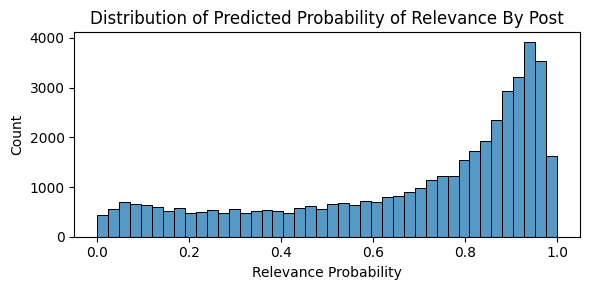

In [17]:
fig, ax = plt.subplots(figsize=(6,3))
sns.histplot(labeled_df, x='related_proba', ax=ax)
ax.set_title("Distribution of Predicted Probability of Relevance By Post")
ax.set_xlabel("Relevance Probability")
plt.tight_layout()
fig.savefig("../corpus/combined/related_proba_dist.png", dpi=300)

In [18]:
labeled_df = labeled_df[labeled_df['related_proba']>0.5]

In [19]:
labeled_df.to_csv("../corpus/combined/combined_corpus_by_name_relevance_filtered.csv", index=False)

### Deduplicate

In [20]:
labeled_df = pd.read_csv("../corpus/combined/combined_corpus_by_name_relevance_filtered.csv")

In [21]:
labeled_df.shape

(33243, 28)

In [22]:
dedup = labeled_df.drop_duplicates(['note_id', 'medicine_name'])
dedup.shape

(31430, 28)

In [23]:
set(labeled_df['id'].unique()) - set(dedup['id'].unique())

{np.int64(40982),
 np.int64(32805),
 np.int64(32806),
 np.int64(32807),
 np.int64(32809),
 np.int64(32811),
 np.int64(32812),
 np.int64(32814),
 np.int64(32815),
 np.int64(32825),
 np.int64(41019),
 np.int64(32829),
 np.int64(41031),
 np.int64(32840),
 np.int64(32851),
 np.int64(32855),
 np.int64(32897),
 np.int64(32940),
 np.int64(32942),
 np.int64(32943),
 np.int64(41151),
 np.int64(41154),
 np.int64(41161),
 np.int64(41163),
 np.int64(32982),
 np.int64(32983),
 np.int64(41174),
 np.int64(41179),
 np.int64(32988),
 np.int64(41183),
 np.int64(32992),
 np.int64(41184),
 np.int64(32994),
 np.int64(32995),
 np.int64(41185),
 np.int64(32998),
 np.int64(41190),
 np.int64(33000),
 np.int64(41192),
 np.int64(33002),
 np.int64(33005),
 np.int64(41197),
 np.int64(33007),
 np.int64(33018),
 np.int64(33045),
 np.int64(41237),
 np.int64(33052),
 np.int64(41252),
 np.int64(41256),
 np.int64(33087),
 np.int64(41280),
 np.int64(41284),
 np.int64(41285),
 np.int64(33094),
 np.int64(41303),
 np.int64(

In [24]:
labeled_df.query('id == 40982')['note_id'].iloc[0]

'dc5452e4a65577f38c51eb927c27fb34aa04794615a594f72030c224d4284499'

In [25]:
labeled_df.query('note_id == "dc5452e4a65577f38c51eb927c27fb34aa04794615a594f72030c224d4284499"')

,id,note_url,ups,note_id,downs,search_keyword,poster,content,created_year,title,...,medicine_en_uname,medicine_category,medicine_type,condition_mentioned,content_language,content_language_confidence,title_language,title_language_confidence,related,related_proba
4108,40937,www.reddit.com/r/alopecia_areata/comments/1mmd...,3,dc5452e4a65577f38c51eb927c27fb34aa04794615a594...,0.0,Mometasone furoate,1ea88cbf1200bf7afc5f58357ca34de632ca73619448d2...,My 17yr old son has been recently been diagnos...,2025,Has anyone used Elocon?,...,Mometasone furoate,eczema,ebm,False,en,0.989778,en,0.950485,True,0.632067
27762,40982,www.reddit.com/r/alopecia_areata/comments/1mmd...,3,dc5452e4a65577f38c51eb927c27fb34aa04794615a594...,0.0,Elocon,1ea88cbf1200bf7afc5f58357ca34de632ca73619448d2...,My 17yr old son has been recently been diagnos...,2025,Has anyone used Elocon?,...,Mometasone furoate,eczema,ebm,False,en,0.989778,en,0.950485,True,0.632067


In [26]:
dedup.to_csv("../corpus/combined/combined_corpus_by_name_relevance_filtered_dedup.csv", index=False)

In [2]:
dedup = pd.read_csv("../corpus/combined/combined_corpus_by_name_relevance_filtered_dedup.csv")

In [28]:
dedup[["note_id", "title", "content"]].drop_duplicates(["note_id"]).to_parquet(
    "../corpus/cleaned/posts_by_noteid.parquet",
    engine='pyarrow',
    index=False
)

In [7]:
notes = dedup.drop_duplicates(["note_id"])
notes.shape

(18038, 28)

In [9]:
notes[notes['source'] == 'reddit'].shape

(5232, 28)

In [10]:
notes[notes['source'] == 'weibo'].shape

(12806, 28)

In [29]:
dedup.columns

Index(['id', 'note_url', 'ups', 'note_id', 'downs', 'search_keyword', 'poster',
       'content', 'created_year', 'title', 'created_utc', 'shared_count',
       'source', 'comments_count', 'language', 'medicine_matches',
       'medicine_name', 'medicine_uname', 'medicine_en_uname',
       'medicine_category', 'medicine_type', 'condition_mentioned',
       'content_language', 'content_language_confidence', 'title_language',
       'title_language_confidence', 'related', 'related_proba'],
      dtype='str')

***note_url is not included for privacy concerns***

In [30]:
dedup[[
    'id', 'ups', 'note_id', 'downs', 'search_keyword', 'poster', 'created_year', 'created_utc',
    'shared_count', 'source', 'comments_count', 'language', 'medicine_matches', 'medicine_name',
    'medicine_uname', 'medicine_en_uname', 'medicine_category', 'medicine_type', 'condition_mentioned',
    'content_language', 'content_language_confidence', 'title_language', 'title_language_confidence',
    'related', 'related_proba'
]].to_csv("../corpus/source_and_cleanup_metadata.csv", index=False)

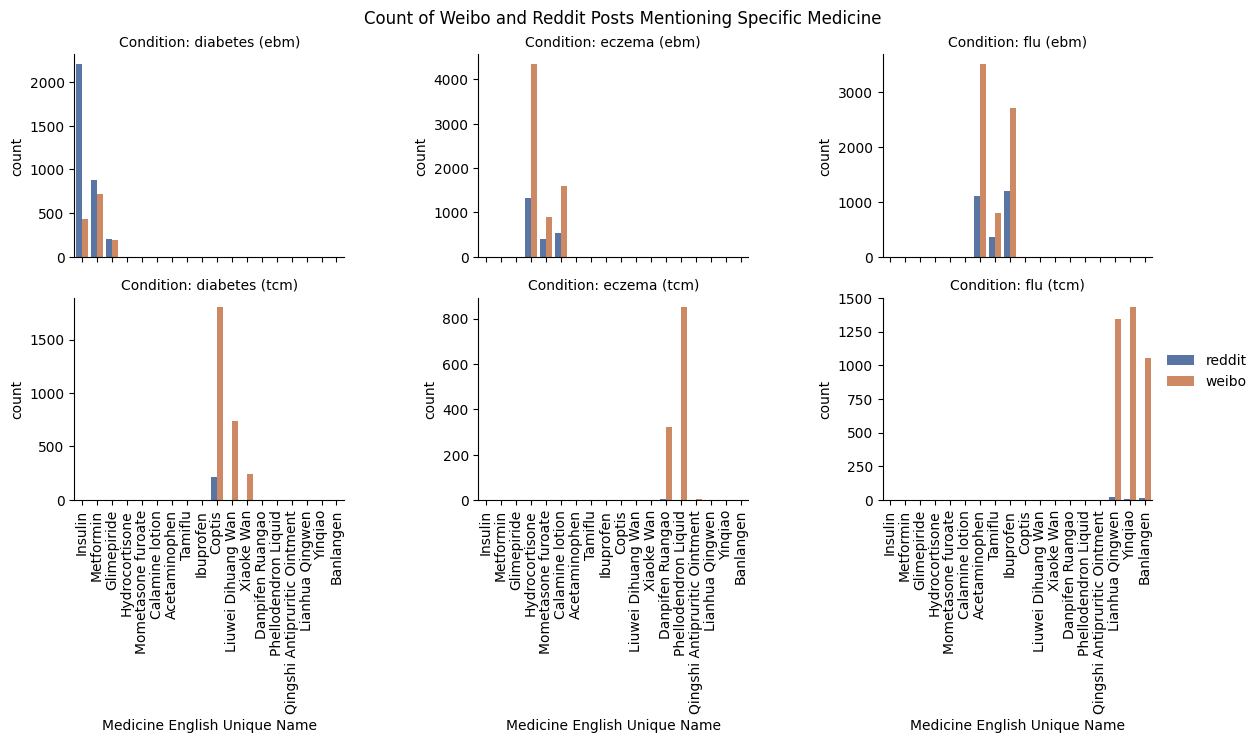

In [3]:
set_plot_english()
g = sns.FacetGrid(dedup.sort_values(by='medicine_category'), row = "medicine_type", col = "medicine_category", height=2.8, aspect=1.4, sharey=False)
sources = ['reddit', 'weibo']
g.map_dataframe(sns.countplot, x="medicine_en_uname", hue="source", hue_order=sources, palette="deep", dodge=True)
g.fig.tight_layout()
labels = dedup['medicine_en_uname'].unique()
g.set(xticks=labels)
g.set_xticklabels(labels, rotation=90)
g.fig.subplots_adjust(top=0.9) 
g.fig.suptitle("Count of Weibo and Reddit Posts Mentioning Specific Medicine")
g.set_titles("Condition: {col_name} ({row_name})")
g.set_xlabels("Medicine English Unique Name")
g.add_legend()
g.savefig("plots/combined_filtered_counts.png", dpi=310)